In [3]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1" 
os.environ['TORCH_USE_CUDA_DSA'] = "1"

# 🎯 Bitirme Projesi: Duygu Bias'lı LLM Decoder Katmanları ile Doğal Duygulu Cevap Üretimi

## 1. Giriş
- **Problem Tanımı:** LLM'ler genellikle nötr cevaplar üretir. Amaç, decoder katmanlarına eklenen ağırlıklı duygu bias'ları ile doğal duygulu cevaplar üretmek.
- **Motivasyon:** İnsan-makine etkileşiminde duygusal tonun önemi.
- **Literatür Özeti:** Controlled text generation, sentiment control, prefix-tuning, bias injection teknikleri.

---

## 2. Teorik Arka Plan
- **LLM Mimarisi:** Encoder-Decoder vs Decoder-only modeller.
- **Decoder Katman Yapısı:** Self-attention, feed-forward, layer norm, bias noktaları.
- **Duygu Temsili:** 
  - One-hot veya soft-weighted vektörler (ör. `[happy:0.6, sad:0.2, angry:0.2]`)
  - Embedding dönüşümü ile bias vektörüne çevrilmesi.
- **Bias Enjeksiyon Noktaları:**
  - Katman girişine ekleme
  - Attention skorlarına ekleme
  - Output logits’e ekleme

---

## 3. Yöntem
### 3.1 Mimari Tasarım
- **Mini Encoder:** Duygu ağırlık listesini alıp bias embedding üreten küçük bir ağ.
- **Bias Enjeksiyonu:** Decoder katmanlarının her birine eklenmesi.
- **Formül:**
  $
  h'_l = h_l + W_b \cdot e_{emotion}
  $
  Burada \( $h_l$ \) katman aktivasyonu, \( $e_{emotion}$ \) duygu embedding’i, \( $W_b$ \) öğrenilebilir ağırlık matrisi.

### 3.2 Veri Seti
- **Temel veri:** Nötr diyalog veri seti (örn. DailyDialog, OpenSubtitles).
- **Ek etiketleme:** Duygu etiketleri (happy, sad, angry, neutral).

### 3.3 Eğitim Stratejisi
- **Fine-tuning:** Mevcut LLM üzerine duygu bias modülü ekleyerek.
- **Loss Fonksiyonu:**
  - Ana dil modelleme loss’u (CrossEntropy)
  - Duygu uyum loss’u (örn. cosine similarity ile hedef duygu embedding’e yakınlık)

---

## 4. Deneysel Kurulum
- **Model:** Küçük boyutlu bir GPT-2 / OPT / LLaMA tabanlı decoder.
- **Ortam:** PyTorch + HuggingFace Transformers.
- **Hyperparametreler:** batch size, learning rate, bias boyutu.

---

## 5. Uygulama Adımları (Kod Hücreleri)
Prompt → Hafif Encoder (duygu çıkarımı) → Bias Encoder (d_model boyutunda vektör)
       → GPT-benzeri Decoder (her katmana bias enjeksiyonu) → Çıktı

# 🚀 Bitirme Projesi: Katman Bazlı Duygu Bias Enjeksiyonu

## Faz 1 – Hafif Encoder Eğitimi (Duygu Çıkarıcı)

### 🎯 Amaç
Girdi metninden **multi-label** duygu dağılımı (`w` vektörü) çıkarabilen hafif bir encoder modeli eğitmek.

### 📚 Veri Seti
- **GoEmotions** (Google Research)
  - Lisans: CC BY 4.0 (makalede kullanılabilir, atıf gerekli)
  - 58k cümle, 27 ince duygu + neutral
  - Multi-label etiketleme

### 🧠 Model
- **distilbert-base-uncased**
  - Lisans: Apache 2.0
  - Hafif, 6GB VRAM’de rahat çalışır
  - Hugging Face Transformers ile kolay fine-tune

### ⚙️ Eğitim Detayları
- **Loss:** `BCEWithLogitsLoss` (multi-label)
- **Optimizer:** AdamW (lr=5e-5)
- **Epoch:** 3–5
- **Batch Size:** 16–32 (VRAM’e göre ayarlanır)
- **Çıkış:** `encoder.pt` (Faz 2’de kullanılacak)

### 📊 Değerlendirme
- **Otomatik:** Micro/macro F1-score
- **Manuel:** Encoder’ın çıkardığı `w` dağılımının mantıklı olup olmadığı

---

## Faz 2 – Encoder + GPT-benzeri Decoder Entegrasyonu

### 🎯 Amaç
Encoder’dan gelen `w` → bias vektörü → GPT-benzeri decoder’ın **her katmanına** enjekte edilerek doğal ve duygulu metin üretmek.

### 🧩 Mimari
1. **EmotionExtractor** (Faz 1’den gelen encoder)
2. **BiasEncoder**
   - `w` → `bias_vec` (d_model boyutunda)
3. **BiasInjector**
   - Bias’ı decoder katman aktivasyonlarına ekler (Residual veya FiLM)
4. **Decoder**
   - GPT-2 / LLaMA gibi saf decoder
   - Bias enjeksiyonu her attention/MLP bloğunda

### ⚙️ Eğitim Stratejisi
- **Başlangıç:** Decoder dondurulur, sadece encoder + bias parametreleri çalışır
- **Opsiyonel:** Eğer insan değerlendirmesi sonucu duygu yansıması zayıfsa, decoder üst katmanları açılarak LM loss ile fine-tune yapılır
- **Loss:**
  - Encoder için: `emotion_loss` (BCEWithLogitsLoss)
  - Decoder için (opsiyonel): `lm_loss` (CrossEntropy)

### 🧪 Test Senaryoları
- **Otomatik:** Sentiment classifier ile hedef duyguya yakınlık
- **Manuel:** İnsan gözüyle duygu tutarlılığı ve doğallık
- **Ablasyon:** 
  - Bias enjeksiyonu her katmanda vs sadece logits öncesi
  - Residual vs FiLM
  - Paylaşılan bias vs katman-özel bias

---

# Faz 1 (Duygu analizi için fine-tunning yapılır)

In [4]:
# venv\Scripts\activate 
# Faz 1: Hafif Encoder Eğitimi
# ============================
os.environ["HF_HOME"] = os.path.join(os.getcwd(), ".hf_cache")
os.environ["TRANSFORMERS_CACHE"] = os.path.join(os.getcwd(), ".hf_cache", "transformers")
os.environ["HF_DATASETS_CACHE"] = os.path.join(os.getcwd(), ".hf_cache", "datasets")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.metrics import f1_score
from transformers import AutoModelForCausalLM, AutoTokenizer
from copy import deepcopy
from transformers import GPT2LMHeadModel, AutoTokenizer
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM, GPT2LMHeadModel
from transformers.cache_utils import DynamicCache

c:\Users\efeka\Documents\AI\venv\Lib\site-packages\transformers\utils\hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [5]:
# 1) Veri seti yükleme (GoEmotions) - cache proje klasöründe
dataset = load_dataset("go_emotions", "simplified", cache_dir="./.hf_cache", download_mode="reuse_dataset_if_exists")  # 27 emotion + neutral
num_emotions = len(dataset["train"].features["labels"].feature.names)

# 2) Tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir="./.hf_cache")

# 3) Tokenize + labels'ı one-hot encode et
def tokenize_and_encode(batch):
    # Tokenize
    tokenized = tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)
    # One-hot encode labels
    labels = torch.zeros((len(batch["labels"]), num_emotions), dtype=torch.float)
    for i, label_list in enumerate(batch["labels"]):
        labels[i, label_list] = 1.0
    tokenized["labels"] = labels
    return tokenized

dataset = dataset.map(tokenize_and_encode, batched=True)

# 4) PyTorch formatına çevir
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

"""
input_ids:     [1012, 4567,    0,    0]
attention_mask:[   1,    1,    0,    0]
"""

# 5) DataLoader'lar
train_loader = DataLoader(dataset["train"], batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(dataset["validation"], batch_size=8)

README.md: 0.00B [00:00, ?B/s]

c:\Users\efeka\Documents\AI\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\efeka\Documents\AI\Final Dance\.hf_cache\hub\datasets--go_emotions. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [6]:
# 3) Model tanımı
class EmotionExtractor(nn.Module):
    def __init__(self, encoder_name, num_emotions):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_emotions)
    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state.mean(dim=1)
        logits = self.classifier(pooled)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmotionExtractor(model_name, num_emotions).to(device)

# 4) Loss ve optimizer
loss_fn = nn.BCEWithLogitsLoss() # çıktıda sigmoid koymadık çünkü BCEWithLogitsLoss bu zaten otomatik loss hesabında log alıyor zaten.
optimizer = AdamW(model.parameters(), lr=5e-5)

if os.path.exists("checkpoint.pt"):
    print("Checkpoint bulundu, kaldığı yerden devam ediliyor...")
    checkpoint = torch.load("checkpoint.pt", map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
else:
    print("Checkpoint bulunamadı, sıfırdan başlanıyor...")
    if os.path.exists("emotion_extractor.pt"):
        print("Önceden eğitilmiş model ağırlıkları yükleniyor...")
        model.load_state_dict(torch.load("emotion_extractor.pt", map_location=device))
    # optimizer zaten sıfırdan başlıyor


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

c:\Users\efeka\Documents\AI\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\efeka\Documents\AI\Final Dance\.hf_cache\transformers\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Checkpoint bulundu, kaldığı yerden devam ediliyor...


In [14]:
# 5) Eğitim döngüsü
for epoch in range(3):
    model.train()
    torch.set_grad_enabled(True)
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].float().to(device)
        
        logits = model(input_ids, attention_mask)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    print(f"Epoch {epoch+1} | Train Loss: {total_loss/len(train_loader):.4f}")
    
    # Validation
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].cpu().numpy()
            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds.extend((probs > 0.5).astype(int))
            trues.extend(labels)
    f1 = f1_score(trues, preds, average="micro")
    print(f"Validation micro-F1: {f1:.4f}")

# 6) Modeli kaydet
    # 6) Model + optimizer + epoch + loss kaydet
    torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': total_loss/len(train_loader)
    }, "checkpoint.pt")
    

Epoch 1 | Train Loss: 0.0607
Validation micro-F1: 0.5582


KeyboardInterrupt: 

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

model.eval()
preds, trues = [], []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].cpu().numpy()
        
        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()
        
        preds.extend((probs > 0.5).astype(int))
        trues.extend(labels)

# Precision, Recall, F1 (micro/macro/weighted)
precision_micro = precision_score(trues, preds, average="micro")
recall_micro    = recall_score(trues, preds, average="micro")
f1_micro        = f1_score(trues, preds, average="micro")

precision_macro = precision_score(trues, preds, average="macro")
recall_macro    = recall_score(trues, preds, average="macro")
f1_macro        = f1_score(trues, preds, average="macro")

print(f"Micro Precision: {precision_micro:.4f}")
print(f"Micro Recall:    {recall_micro:.4f}")
print(f"Micro F1:        {f1_micro:.4f}")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall:    {recall_macro:.4f}")
print(f"Macro F1:        {f1_macro:.4f}")

# Ayrıntılı rapor (her sınıf için)
print(classification_report(trues, preds, target_names=[str(i) for i in range(num_emotions)]))

Micro Precision: 0.6517
Micro Recall:    0.4881
Micro F1:        0.5582
Macro Precision: 0.6089
Macro Recall:    0.4171
Macro F1:        0.4747
              precision    recall  f1-score   support

           0       0.68      0.78      0.73       488
           1       0.75      0.84      0.79       303
           2       0.51      0.38      0.43       195
           3       0.43      0.26      0.33       303
           4       0.46      0.26      0.33       397
           5       0.46      0.41      0.43       153
           6       0.61      0.27      0.37       152
           7       0.51      0.56      0.54       248
           8       0.76      0.42      0.54        77
           9       0.45      0.09      0.15       163
          10       0.42      0.42      0.42       292
          11       0.59      0.34      0.43        97
          12       0.79      0.31      0.45        35
          13       0.33      0.22      0.26        96
          14       0.74      0.47      0.57  

c:\Users\efeka\Documents\AI\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


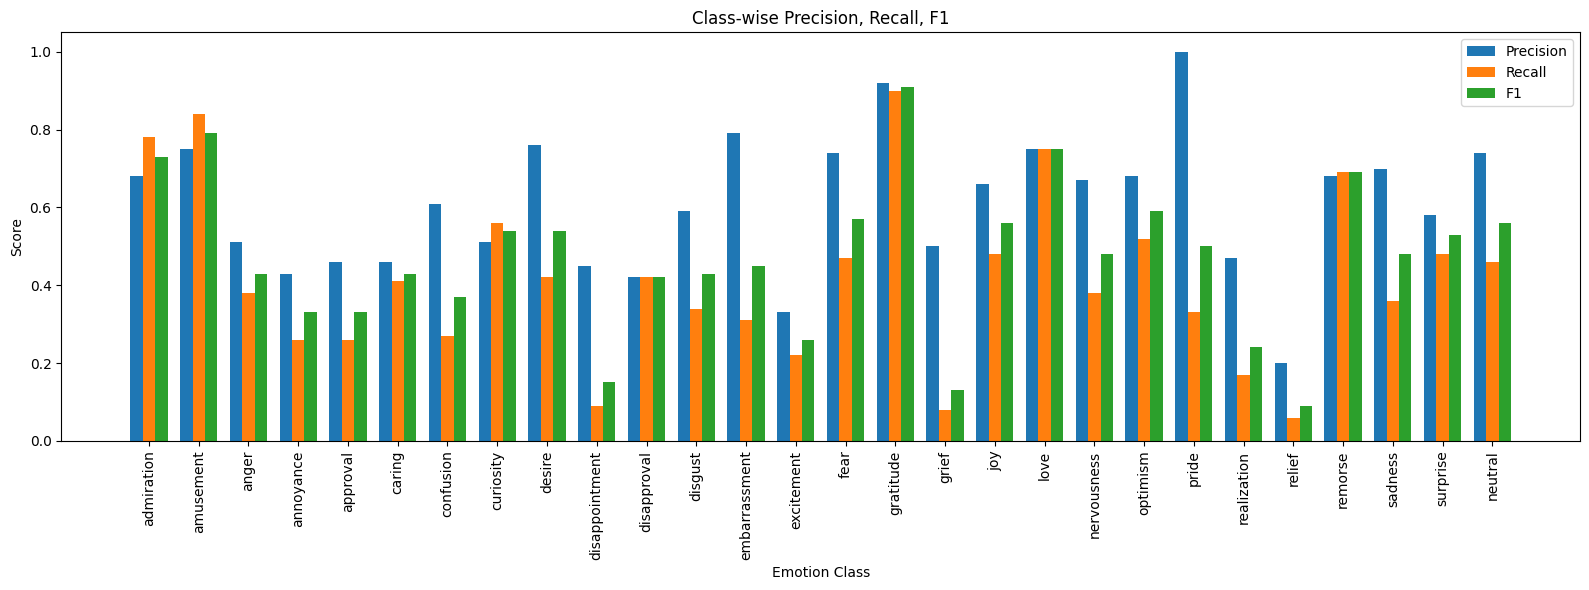

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

# GoEmotions dataset'i yükle (simplified versiyon için subset parametresi kullanılabilir)
dataset = load_dataset("go_emotions", "simplified")

# Label isimlerini çek
emotion_labels = dataset['train'].features['labels'].feature.names
print(emotion_labels)  # ['admiration','amusement','anger',...,'neutral']

# Class-wise metrikler (senin çıktından alınan değerler)
precision = [0.68,0.75,0.51,0.43,0.46,0.46,0.61,0.51,0.76,0.45,
             0.42,0.59,0.79,0.33,0.74,0.92,0.50,0.66,0.75,0.67,
             0.68,1.00,0.47,0.20,0.68,0.70,0.58,0.74]
recall    = [0.78,0.84,0.38,0.26,0.26,0.41,0.27,0.56,0.42,0.09,
             0.42,0.34,0.31,0.22,0.47,0.90,0.08,0.48,0.75,0.38,
             0.52,0.33,0.17,0.06,0.69,0.36,0.48,0.46]
f1        = [0.73,0.79,0.43,0.33,0.33,0.43,0.37,0.54,0.54,0.15,
             0.42,0.43,0.45,0.26,0.57,0.91,0.13,0.56,0.75,0.48,
             0.59,0.50,0.24,0.09,0.69,0.48,0.53,0.56]

x = np.arange(len(emotion_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(16,6))
ax.bar(x - width, precision, width, label='Precision')
ax.bar(x, recall, width, label='Recall')
ax.bar(x + width, f1, width, label='F1')

ax.set_xlabel('Emotion Class')
ax.set_ylabel('Score')
ax.set_title('Class-wise Precision, Recall, F1')
ax.set_xticks(x)
ax.set_xticklabels(emotion_labels, rotation=90)  # sınıf isimlerini yaz
ax.legend()

plt.tight_layout()
plt.savefig("classwise_metrics.png", dpi=300)
plt.show()

# Faz 2 / deneme 1 (en sonda duygu bias'ı eklenir)

In [ ]:
# Faz 2/ deneme 1: Encoder + Decoder Entegrasyonu
# =====================================
# 1) Bias Encoder
class BiasEncoder(nn.Module):
    def __init__(self, num_emotions, d_model):
        super().__init__()
        self.linear = nn.Linear(num_emotions, d_model)
    def forward(self, w):
        return torch.tanh(self.linear(w))

# 2) Bias Injector
class BiasInjector(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1))
    def forward(self, hidden_states, bias_vec):
        return hidden_states + self.gamma * bias_vec.unsqueeze(1)

In [ ]:
# 3) Entegre Model
class EmotionConditionedDecoder(nn.Module):
    def __init__(self, decoder_name, emotion_extractor, num_emotions):
        super().__init__()
        self.emotion_extractor = emotion_extractor
        self.decoder = AutoModelForCausalLM.from_pretrained(decoder_name)
        self.bias_encoder = BiasEncoder(num_emotions, self.decoder.config.hidden_size)
        self.bias_injector = BiasInjector(self.decoder.config.hidden_size)
    def forward(self, input_ids, attention_mask):
        # 1) Duygu çıkarımı
        with torch.no_grad():
            logits = self.emotion_extractor(input_ids, attention_mask)
            w = torch.sigmoid(logits)
        # 2) Bias üretimi
        bias_vec = self.bias_encoder(w)
        # 3) Decoder forward
        outputs = self.decoder.transformer.wte(input_ids) + self.decoder.transformer.wpe(torch.arange(input_ids.size(1), device=input_ids.device))
        hidden_states = outputs
        for block in self.decoder.transformer.h:
            hidden_states = block(hidden_states)[0]
            hidden_states = self.bias_injector(hidden_states, bias_vec)
        hidden_states = self.decoder.transformer.ln_f(hidden_states)
        logits = self.decoder.lm_head(hidden_states)
        return logits

In [ ]:
# 4) Kullanım örneği
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Faz 1'den eğitilmiş encoder'ı yükle
encoder = EmotionExtractor(model_name, num_emotions).to(device)
encoder.load_state_dict(torch.load("emotion_extractor.pt", map_location=device))
encoder.eval()

tokenizer_dec = AutoTokenizer.from_pretrained("gpt2")
model_full = EmotionConditionedDecoder("gpt2", encoder, num_emotions).to(device)

prompt = "Today the weather warms my heart."
inputs = tokenizer_dec(prompt, return_tensors="pt").to(device)
logits = model_full(inputs["input_ids"], inputs["attention_mask"])
pred_ids = torch.argmax(logits[:, -1, :], dim=-1)
print("Next token prediction:", tokenizer_dec.decode(pred_ids))

# faz 2 / deneme 2 (Q ve K değerleri bulunurken x değerleri ile emo_bias toplanarak hesaplama yapılır ve embedding pozisyonları ayarlanır)

In [ ]:
# Hafif encoder (duygu çıkarıcı) iskeleti
# Not: Kendi Faz 1'de eğittiğin modeli buraya yükleyebilirsin.
# Şimdilik demonun akması için logits üretip sigmoid ile w çıkaran basit bir yapı bırakıyorum.

class EmotionExtractor(nn.Module):
    def __init__(self, encoder_name="distilbert-base-uncased", num_emotions=27):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_emotions)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state.mean(dim=1)
        logits = self.classifier(pooled)
        return logits  # BCEWithLogitsLoss için uygundur; inference'ta sigmoid uygularız.

# Örnek: Eğitilmiş ağırlıkları yükle (varsa)
# extractor = EmotionExtractor()
# extractor.load_state_dict(torch.load("emotion_extractor.pt", map_location=device))
# extractor.eval().to(device)

In [ ]:
# Emotion vektöründen (w) Q ve K için başlık boyutunda (n_head, head_dim) ofset üreten modül
class EmotionToQK(nn.Module):
    def __init__(self, num_emotions, n_head, head_dim, shared=True):
        super().__init__()
        self.n_head = n_head
        self.head_dim = head_dim
        out_dim = n_head * head_dim
        # Paylaşılan projeksiyon (tüm katmanlar aynı) — basit başlangıç
        # İstersen katman-özel versiyon için her katmana ayrı modül koyarız.
        self.proj_q = nn.Linear(num_emotions, out_dim)
        self.proj_k = nn.Linear(num_emotions, out_dim)
        self.shared = shared

    def forward(self, w):  # w: [B, num_emotions] (sigmoid sonrası)
        # Çıkışlar: [B, n_head, head_dim]
        q_add = self.proj_q(w).view(w.size(0), self.n_head, self.head_dim)
        k_add = self.proj_k(w).view(w.size(0), self.n_head, self.head_dim)
        return q_add, k_add

In [ ]:
# GPT-2 Attention forward'ını q/k enjeksiyonu ile patch'leme
# Mantık:
# - extract w (duygu) → emotion_to_qk → (q_add, k_add): [B, n_head, head_dim]
# - Orijinal attention'da q, k, v hesaplandıktan sonra q += q_add[:, :, :].unsqueeze(2)
#   ve k += k_add[:, :, :].unsqueeze(2) ile seq_len boyunca yayınlıyoruz (broadcast)
# - Böylece her başlıkta q/k vektörlerine sabit bir (duyguya bağlı) ofset eklenmiş oluyor.

def patch_gpt2_attention_with_qk(model: GPT2LMHeadModel, emotion_to_qk: EmotionToQK):
    """
    model: GPT2LMHeadModel
    emotion_to_qk: EmotionToQK (paylaşılan modül)
    """
    for layer_idx, block in enumerate(model.transformer.h):
        attn = block.attn
        orig_forward = attn.forward  # orijinal forward'ı sakla

        def forward_with_emotion(self, hidden_states, layer_past=None, attention_mask=None, head_mask=None,
                                 encoder_hidden_states=None, encoder_attention_mask=None, use_cache=False,
                                 output_attentions=False):
            # HF GPT-2 Attention forward'ının sadeleştirilmiş bir varyantı.
            # Bazı uç parametreleri (encoder cross-attn vb.) kullanmıyoruz.
            assert encoder_hidden_states is None, "Cross-attention bu patch'te desteklenmiyor."

            # c_attn: Linear -> qkv projeksiyonu
            # shape: [B, T, 3*embed_dim]  -> split -> [B, T, embed_dim] x 3
            qkv = self.c_attn(hidden_states)
            query, key, value = qkv.split(self.split_size, dim=2)

            # [B, T, n_head, head_dim] -> sonra [B, n_head, T, head_dim]
            def shape(x):
                new_x_shape = x.size()[:-1] + (self.num_heads, x.size(-1) // self.num_heads)
                x = x.view(*new_x_shape)
                return x.permute(0, 2, 1, 3)

            def unshape(x):
                x = x.permute(0, 2, 1, 3).contiguous()
                new_x_shape = x.size()[:-2] + (x.size(-2) * x.size(-1),)
                return x.view(*new_x_shape)

            query = shape(query)
            key = shape(key)
            value = shape(value)

            # EMOTION ENJEKSIYONU (Q/K) — beklenen: self._emotion_w: [B, num_emotions] set edilmiş olsun
            if hasattr(self, "_emotion_w") and self._emotion_w is not None:
                w = self._emotion_w  # [B, num_emotions]
                q_add, k_add = self._emotion_to_qk(w)  # [B, n_head, head_dim], [B, n_head, head_dim]
                # Broadcast seq_len ekseni boyunca:
                query = query + q_add.unsqueeze(2)
                key   = key   + k_add.unsqueeze(2)

            # Scaled dot-product attention
            if self.scale_attn_logits:
                query = query / (float(value.size(-1)) ** 0.5)

            attn_weights = torch.matmul(query, key.transpose(-1, -2))  # [B, n_head, T, T]

            if attention_mask is not None:
                attn_weights = attn_weights + attention_mask

            attn_probs = nn.Softmax(dim=-1)(attn_weights)
            attn_probs = self.attn_dropout(attn_probs)

            attn_output = torch.matmul(attn_probs, value)  # [B, n_head, T, head_dim]
            attn_output = unshape(attn_output)             # [B, T, embed_dim]
            attn_output = self.c_proj(attn_output)
            attn_output = self.resid_dropout(attn_output)

            outputs = (attn_output,)

            if use_cache:
                outputs += ((key, value),)
            if output_attentions:
                outputs += (attn_probs,)
            return outputs

        # Monkey-patch et
        attn.forward = forward_with_emotion.__get__(attn, type(attn))
        # Attention modülüne emotion projeksiyonlarını enjekte et (paylaşılan modüle referans)
        attn._emotion_to_qk = emotion_to_qk
        attn._emotion_w = None  # runtime'da set edilecek

In [ ]:
# Modeli kur ve patch uygula
gpt2_name = "gpt2"  # İstersen "gpt2-medium" vb. ama VRAM'e dikkat et
lm = AutoModelForCausalLM.from_pretrained(gpt2_name).to(device).eval()

# GPT-2 config'ten başlık bilgilerini al
n_head = lm.config.n_head
n_layer = lm.config.n_layer
head_dim = lm.config.n_embd // lm.config.n_head

# Emotion tarafı (örnek)
num_emotions = 27  # GoEmotions gibi
emotion_to_qk = EmotionToQK(num_emotions=num_emotions, n_head=n_head, head_dim=head_dim).to(device)

# Patch uygula
patch_gpt2_attention_with_qk(lm, emotion_to_qk)

# Tokenizer
tok = AutoTokenizer.from_pretrained(gpt2_name)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

In [ ]:
# Runtime'da emotion_w'yi set eden yardımcı fonksiyon
def set_emotion_on_model(lm: GPT2LMHeadModel, w: torch.Tensor):
    """
    lm: patched GPT-2 model
    w: [B, num_emotions] — sigmoid sonrası emotion dağılımı
    """
    for block in lm.transformer.h:
        attn = block.attn
        attn._emotion_w = w  # referansla aynı batch için kullanılacak

def clear_emotion_on_model(lm: GPT2LMHeadModel):
    for block in lm.transformer.h:
        block.attn._emotion_w = None

In [ ]:
# Basit üretim (greedy) örneği — gerçek kullanımda sampling/temperature ekleyebilirsin
@torch.no_grad()
def generate_with_emotion(prompt: str, w: torch.Tensor, max_new_tokens=50, temperature=1.0):
    """
    prompt: giriş metni (str)
    w: [1, num_emotions] (tek örnek için) — sigmoid sonrası emotion dağılımı
    """
    lm.eval()
    inputs = tok(prompt, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]

    # Emotion set et
    set_emotion_on_model(lm, w)

    for _ in range(max_new_tokens):
        outputs = lm(input_ids=input_ids)
        logits = outputs.logits[:, -1, :] / max(1e-6, temperature)
        next_id = torch.argmax(logits, dim=-1, keepdim=True)
        input_ids = torch.cat([input_ids, next_id], dim=1)
        if next_id.item() == tok.eos_token_id:
            break

    # Emotion temizle
    clear_emotion_on_model(lm)

    return tok.decode(input_ids[0], skip_special_tokens=True)

# Demo: w'yi manuel verelim (örneğin "happy" baskın)
# Not: Gerçekte, EmotionExtractor ile prompt'tan w çıkarıp sigmoid uygulayacaksın.
w_demo = torch.zeros(1, num_emotions, device=device)
w_demo[0, 0] = 0.9  # örnek olarak 0. indeks "happy" olsun
w_demo = w_demo  # zaten [0..1] arası bir dağılım farz edelim

out = generate_with_emotion("Today the weather warms my heart.", w_demo, max_new_tokens=40)
print(out)

In [ ]:
# Opsiyonel: Encoder'ı bağlayıp w'yi otomatik çıkaralım
# Not: Kendi eğittiğin EmotionExtractor checkpoint'ini yüklemen en doğrusu.

# extractor = EmotionExtractor(encoder_name="distilbert-base-uncased", num_emotions=num_emotions).to(device).eval()
# extractor.load_state_dict(torch.load("emotion_extractor.pt", map_location=device))

@torch.no_grad()
def emotion_from_text(text: str, extractor: EmotionExtractor, max_len=128):
    enc_tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
    batch = enc_tok(text, return_tensors="pt", padding=True, truncation=True, max_length=max_len).to(device)
    logits = extractor(batch["input_ids"], batch["attention_mask"])
    w = torch.sigmoid(logits)  # [B, num_emotions]
    return w

# Örnek kullanım (eğer extractor yüklediysen):
# w_auto = emotion_from_text("Today the weather warms my heart.", extractor)
# out_auto = generate_with_emotion("Today the weather warms my heart.", w_auto, max_new_tokens=40)
# print(out_auto)

# Tüm yapı / deneme 1
 Uçtan uca: Faz 1 encoder + Only-K bazlı bias enjeksiyon (patched model) + tam ayrı "vanilla" model
 - Plain çıktı için tamamen PATCH'SİZ ayrı bir GPT-2 (lm_base) kullanılır.
 - Bias'lı çıktı için ayrı bir GPT-2 (lm_bias) patch'lenir; duygusuzken bile plain'e karışmaz.
 - HF generate her iki modda da kullanılır (mask/past yönetimi güvenli).
 - Only-K ofset + küçük alpha + normalize w (stabil).


In [2]:
from transformers import LogitsProcessor, LogitsProcessorList
import torch
from transformers import RepetitionPenaltyLogitsProcessor
import re
import string

class PunctuationRepeatSuppressor(LogitsProcessor):
    def __init__(self, tokenizer, max_consecutive_punct=2, window=6, penalty=2.5):
        super().__init__()
        self.tok = tokenizer
        self.max_consec = max_consecutive_punct
        self.window = window
        self.penalty = penalty

        # ASCII noktalama + ek Unicode semboller
        extra_punct = "…—–“”’"
        punct_chars = string.punctuation + extra_punct
        self.punct_re = re.compile(r'^[' + re.escape(punct_chars) + r']+$')

        # Token id → is_punct ön-haritalama
        self.is_punct = {}
        for tid in range(self.tok.vocab_size):
            tok = self.tok.convert_ids_to_tokens(tid)
            self.is_punct[tid] = bool(self.punct_re.match(tok))

    def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor) -> torch.FloatTensor:
        bsz = input_ids.size(0)
        for b in range(bsz):
            seq = input_ids[b].tolist()
            # 1) Ardışık noktalama uzunluğu
            consec = 0
            i = len(seq) - 1
            while i >= max(0, len(seq) - self.window):
                tid = seq[i]
                if self.is_punct.get(tid, False):
                    consec += 1
                    i -= 1
                else:
                    break
            if consec >= self.max_consec:
                idxs = [tid for tid, isp in self.is_punct.items() if isp]
                scores[b, idxs] -= self.penalty

            # 2) Aynı token tekrarını bastır
            if len(seq) >= 2 and seq[-1] == seq[-2]:
                scores[b, seq[-1]] -= self.penalty

        return scores

torch.set_grad_enabled(False)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# (Opsiyonel) HF cache'i proje klasörüne sabitle
os.environ.setdefault("HF_HOME", os.path.join(os.getcwd(), ".hf_cache"))

# ===================== Encoder (Faz 1) =====================

class EmotionExtractor(nn.Module):
    def __init__(self, encoder_name="distilbert-base-uncased", num_emotions=28):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_emotions)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state.mean(dim=1)
        logits = self.classifier(pooled)
        return logits  # training: BCEWithLogitsLoss, inference: sigmoid

num_emotions = 28  # Faz 1 ile aynı olmalı
extractor = EmotionExtractor(num_emotions=num_emotions).to(device).eval()
checkpoint = torch.load("checkpoint.pt", map_location=device)
extractor.load_state_dict(checkpoint['model_state_dict'])

# Encoder tokenizer (bir kere yükle)
enc_tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# ===================== İki Ayrı GPT-2 =====================

gpt2_name = "gpt2"

# 1) Plain için tamamen patch'siz model/tokenizer
tok_base = AutoTokenizer.from_pretrained(gpt2_name)
if tok_base.pad_token is None:
    tok_base.pad_token = tok_base.eos_token
lm_base: GPT2LMHeadModel = AutoModelForCausalLM.from_pretrained(gpt2_name).to(device).eval()

# 2) Bias'lı üretim için ayrı bir model/tokenizer (yalnızca bu patch'lenir)
tok_bias = AutoTokenizer.from_pretrained(gpt2_name)
if tok_bias.pad_token is None:
    tok_bias.pad_token = tok_bias.eos_token
lm_bias: GPT2LMHeadModel = AutoModelForCausalLM.from_pretrained(gpt2_name).to(device).eval()

# ===================== Q/K Ofset Modülü =====================

class EmotionToQK(nn.Module):
    def __init__(self, num_emotions, n_head, head_dim):
        super().__init__()
        out_dim = n_head * head_dim
        self.n_head = n_head
        self.head_dim = head_dim
        self.proj_q = nn.Linear(num_emotions, out_dim)
        self.proj_k = nn.Linear(num_emotions, out_dim)

    def forward(self, w):  # w: [B, num_emotions], sigmoid sonrası
        q_add = self.proj_q(w).view(w.size(0), self.n_head, self.head_dim)
        k_add = self.proj_k(w).view(w.size(0), self.n_head, self.head_dim)
        return q_add, k_add

# ===================== Patch: GPT-2 Attention (Only-K bias) =====================

EMOTION_ALPHA = 0.06  # daha da konservatif; 0.04–0.10 arası dene

def patch_gpt2_attention_with_qk(model: GPT2LMHeadModel, emotion_to_qk: EmotionToQK, apply_layers=range(6, 12)):
    for li, block in enumerate(model.transformer.h):
        if li not in apply_layers:
            continue

        attn = block.attn
        original_forward = attn.forward  # orijinal forward referansı

        def forward_with_emotion(
            self,
            hidden_states,
            layer_past=None,
            attention_mask=None,
            head_mask=None,
            encoder_hidden_states=None,
            encoder_attention_mask=None,
            use_cache=False,
            output_attentions=False,
            **kwargs,
        ):
            # Duygu yoksa orijinal forward'a dön (plain davranış korunur)
            if not (hasattr(self, "_emotion_w") and self._emotion_w is not None):
                return original_forward(
                    hidden_states=hidden_states,
                    layer_past=layer_past,
                    attention_mask=attention_mask,
                    head_mask=head_mask,
                    encoder_hidden_states=encoder_hidden_states,
                    encoder_attention_mask=encoder_attention_mask,
                    use_cache=use_cache,
                    output_attentions=output_attentions,
                    **kwargs,
                )

            # Cross-attention yok
            if encoder_hidden_states is not None:
                raise AssertionError("Cross-attention bu patch'te desteklenmiyor.")

            # QKV projeksiyonları
            query, key, value = self.c_attn(hidden_states).split(self.split_size, dim=2)

            def shape(x):
                new_x_shape = x.size()[:-1] + (self.num_heads, x.size(-1) // self.num_heads)
                x = x.view(*new_x_shape)
                return x.permute(0, 2, 1, 3)  # [B, n_head, T, head_dim]

            def unshape(x):
                x = x.permute(0, 2, 1, 3).contiguous()
                new_x_shape = x.size()[:-2] + (x.size(-2) * x.size(-1),)
                return x.view(*new_x_shape)  # [B, T, embed_dim]

            query = shape(query)
            key   = shape(key)
            value = shape(value)

            # Only-K ofset (stabil): zero-mean + küçük alpha
            w = self._emotion_w  # [B, num_emotions]
            alpha = getattr(self, "_emotion_alpha", EMOTION_ALPHA)
            w = w.to(next(self._emotion_to_qk.parameters()).dtype)
            _, k_add = self._emotion_to_qk(w)
            k_add = k_add - k_add.mean(dim=-1, keepdim=True)
            # Patch içindeki Only-K kısmını şu şekilde sıkılaştır:
            # (forward_with_emotion içinde, k_add hesaplandıktan hemen sonra)

            # Zero-mean zaten var:
            k_add = k_add - k_add.mean(dim=-1, keepdim=True)

            # L2 norm clamp
            max_norm = 0.8  # 0.5–1.0 arası dene
            norm = k_add.norm(p=2, dim=-1, keepdim=True).clamp_min(1e-6)
            scale = (max_norm / norm).clamp(max=1.0)
            k_add = k_add * scale

            # Tanh compression (ekstra güvenlik)
            k_add = torch.tanh(k_add)

            # Son ölçekleme
            alpha = getattr(self, "_emotion_alpha", EMOTION_ALPHA)
            k_add = (alpha * k_add).to(key.dtype)

            key = key + k_add.unsqueeze(2) #B, n_head, 1, head_dim] → T boyunca yayınlanır

            # Geçmiş ekle
            if layer_past is not None:
                past_key, past_value = layer_past
                key = torch.cat((past_key, key), dim=-2)
                value = torch.cat((past_value, value), dim=-2)
            present = (key, value) if use_cache else None

            # Ölçekleme
            if getattr(self, "scale_attn_weights", False):
                query = query / (value.size(-1) ** 0.5)

            # Causal mask
            qlen, klen = query.size(-2), key.size(-2)
            causal_mask = self.bias[:, :, klen - qlen : klen, :klen]
            attn_weights = torch.matmul(query, key.transpose(-1, -2)) + causal_mask

            # Dış mask
            if attention_mask is not None:
                attn_weights = attn_weights + attention_mask

            attn_probs = nn.Softmax(dim=-1)(attn_weights)
            attn_probs = self.attn_dropout(attn_probs)

            attn_output = torch.matmul(attn_probs, value)
            attn_output = unshape(attn_output)
            attn_output = self.c_proj(attn_output)
            attn_output = self.resid_dropout(attn_output)

            outputs = (attn_output, present)
            if output_attentions:
                outputs = outputs + (attn_probs,)
            return outputs

        # Patch ve runtime değişkenleri
        attn.forward = forward_with_emotion.__get__(attn, type(attn))
        attn._emotion_to_qk = emotion_to_qk
        attn._emotion_w = None
        attn._emotion_alpha = EMOTION_ALPHA

EMOTION_ALPHA = 0.06  # taban alpha
BASE_BIAS_RATE = 1.0  # manuel çarpan

def adaptive_bias_rate(w, base_rate=BASE_BIAS_RATE):
    eps = 1e-8
    w_norm = w / (w.sum(dim=-1, keepdim=True) + eps)
    H = -(w_norm * (w_norm + eps).log()).sum(dim=-1)  # entropi
    H_norm = H / torch.log(torch.tensor(w.size(-1), dtype=w.dtype, device=w.device))
    rate = base_rate * (1.0 - H_norm)  # sivrilik arttıkça bias azalır
    return rate.clamp(0.0, 1.0)

def set_emotion_on_model(model: GPT2LMHeadModel, w: torch.Tensor, base_rate: float = BASE_BIAS_RATE):
    w = torch.clamp(w, 1e-4, 1 - 1e-4)
    w = w / (w.sum(dim=-1, keepdim=True) + 1e-8)
    bias_rate = adaptive_bias_rate(w, base_rate=base_rate)

    for block in model.transformer.h:
        block.attn._emotion_w = w
        # Norm clamp: k_add vektörlerinin aşırı büyümesini engelle
        block.attn._emotion_alpha = EMOTION_ALPHA * bias_rate[0].item()

def clear_emotion_on_model(model: GPT2LMHeadModel):
    for block in model.transformer.h:
        block.attn._emotion_w = None

# Patch yalnızca bias modeline uygulanır
n_head = lm_bias.config.n_head
head_dim = lm_bias.config.n_embd // lm_bias.config.n_head
emotion_to_qk = EmotionToQK(num_emotions=num_emotions, n_head=n_head, head_dim=head_dim).to(device)
patch_gpt2_attention_with_qk(lm_bias, emotion_to_qk)

# ===================== Üretim Fonksiyonları (HF generate) =====================

@torch.no_grad()
def generate_plain_gpt2(prompt, max_new_tokens=60):
    inputs = tok_base(prompt, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    processors = LogitsProcessorList([
        RepetitionPenaltyLogitsProcessor(1.25),
        PunctuationRepeatSuppressor(tok_base, max_consecutive_punct=2, window=6, penalty=2.5),
    ])

    out_ids = lm_base.generate(
        **inputs,
        do_sample=True,
        temperature=0.6,
        top_k=20,
        top_p=0.8,
        typical_p=0.95,              # HF sürümün destekliyorsa
        logits_processor=processors,
        no_repeat_ngram_size=4,
        repetition_penalty=1.25,
        max_new_tokens=max_new_tokens,
        min_new_tokens=10,
        pad_token_id=tok_base.eos_token_id,
        eos_token_id=tok_base.eos_token_id,
        return_dict_in_generate=False,
    )
    cont = out_ids[0, inputs["input_ids"].shape[1]:]
    return tok_base.decode(cont, skip_special_tokens=True, clean_up_tokenization_spaces=False)


@torch.no_grad()
def generate_with_encoder(prompt: str, max_new_tokens=60, temperature=0.8, top_k=40, top_p=0.92):
    # Encoder → w
    enc_inputs = enc_tok(prompt, return_tensors="pt", truncation=True, padding=True, max_length=128)
    enc_inputs = {k: v.to(device) for k, v in enc_inputs.items()}
    w = torch.sigmoid(extractor(enc_inputs["input_ids"], enc_inputs["attention_mask"]))  # [1, num_emotions]

    # Bias'ı sadece lm_bias üzerinde aç
    set_emotion_on_model(lm_bias, w)

    # Generate (HF)
    inputs = tok_bias(prompt, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    out_ids = lm_bias.generate(
    **inputs,
    do_sample=True,
    temperature=0.7,       # 0.8 → 0.7
    top_k=25,              # 40 → 25
    top_p=0.85,            # 0.92 → 0.85
    no_repeat_ngram_size=3,# 2 → 3
    repetition_penalty=1.1,
    max_new_tokens=max_new_tokens,
    pad_token_id=tok_bias.eos_token_id,
    eos_token_id=tok_bias.eos_token_id,
    return_dict_in_generate=False,
)

    # Temizlik
    clear_emotion_on_model(lm_bias)

    cont = out_ids[0, inputs["input_ids"].shape[1]:]
    return tok_bias.decode(cont, skip_special_tokens=True, clean_up_tokenization_spaces=True)

# ===================== Hızlı Test =====================

if __name__ == "__main__":
    print("Vanilla GPT-2 (tamamen patch'siz) çıktı:")
    print(generate_plain_gpt2("Today the weather warms my heart.", max_new_tokens=60))

    print("\nBias'lı Only-K enjeksiyonlu çıktı:")
    print(generate_with_encoder("Today the weather warms my heart.", max_new_tokens=60))

A custom logits processor of type <class 'transformers.generation.logits_process.RepetitionPenaltyLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.RepetitionPenaltyLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.RepetitionPenaltyLogitsProcessor'> to see related `.generate()` flags.


Vanilla GPT-2 (tamamen patch'siz) çıktı:
 It's been a long day, but I'm so glad to be back in town!
I've had some really nice conversations with people from all over here about how they feel when you're out and your home is on fire or if it means that there are more of us at work than ever

Bias'lı Only-K enjeksiyonlu çıktı:
 I everythingeverythingeveryeveryevery every Every Every Any Anything Everything Everything Everything Everywhere Everywhere Everywhere everywhere everywhere everywhere all All ALL EVERY ANY EVER Ever Never Never Never never ever again once twice times ways way direction direction direction directions courses course Course Cour Cour CourCourCourCour Cour Courcourcourtcourtcourt court Court Court


# Tüm yapı / deneme 2

In [ ]:
class EmotionExtractor(nn.Module):
    def __init__(self, encoder_name="distilbert-base-uncased", num_emotions=28):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_emotions)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state.mean(dim=1)
        logits = self.classifier(pooled)
        return logits
# ===================== Emotion Encoder =====================
# Tek cache konumu
CACHE_DIR = "./.hf_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def load_tokenizer(model_name):
    model_path = os.path.join(CACHE_DIR, "transformers", f"models--{model_name.replace('/', '--')}")
    if os.path.exists(model_path):
        print(f"[CACHE] {model_name} bulundu, internetten indirmeden yükleniyor...")
        return AutoTokenizer.from_pretrained(model_name, cache_dir=CACHE_DIR, local_files_only=True)
    else:
        print(f"[DOWNLOAD] {model_name} indiriliyor...")
        return AutoTokenizer.from_pretrained(model_name, cache_dir=CACHE_DIR)

def load_model(model_name, causal=True):
    model_path = os.path.join(CACHE_DIR, "transformers", f"models--{model_name.replace('/', '--')}")
    if os.path.exists(model_path):
        print(f"[CACHE] {model_name} bulundu, internetten indirmeden yükleniyor...")
        if causal:
            return AutoModelForCausalLM.from_pretrained(model_name, cache_dir=CACHE_DIR, local_files_only=True)
        else:
            return AutoModel.from_pretrained(model_name, cache_dir=CACHE_DIR, local_files_only=True)
    else:
        print(f"[DOWNLOAD] {model_name} indiriliyor...")
        if causal:
            return AutoModelForCausalLM.from_pretrained(model_name, cache_dir=CACHE_DIR)
        else:
            return AutoModel.from_pretrained(model_name, cache_dir=CACHE_DIR)

# ===================== Emotion Encoder =====================
model_name = "distilbert-base-uncased"
num_emotions = 28

enc_tok = load_tokenizer(model_name)

# Modeli oluştur ve checkpoint'i yükle
extractor = EmotionExtractor(encoder_name=model_name, num_emotions=num_emotions)
extractor.encoder = load_model(model_name, causal=False)

checkpoint = torch.load("checkpoint.pt", map_location="cpu")
extractor.load_state_dict(checkpoint['model_state_dict'])

# Cihaza gönder ve eval moduna al
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
extractor.to(device)
extractor.eval()

# ===================== GPT-2 Modelleri =====================
gpt2_name = "gpt2"

tok_base = load_tokenizer(gpt2_name)
if tok_base.pad_token is None:
    tok_base.pad_token = tok_base.eos_token
lm_base = load_model(gpt2_name, causal=True).to(device).eval()

tok_bias = load_tokenizer(gpt2_name)
if tok_bias.pad_token is None:
    tok_bias.pad_token = tok_bias.eos_token
lm_bias = load_model(gpt2_name, causal=True).to(device).eval()


# ===================== Prefix-KV Modülü =====================
class EmotionToPrefixKV(nn.Module):
    def __init__(self, num_emotions, n_head, head_dim, prefix_len=4):
        super().__init__()
        self.n_head = n_head
        self.head_dim = head_dim
        self.prefix_len = prefix_len
        out_dim = n_head * head_dim * 2
        self.proj = nn.Linear(num_emotions, out_dim)

    def forward(self, w):
        B = w.size(0)
        kv = self.proj(w)
        kv = kv.view(B, self.n_head, 2, self.head_dim)
        k, v = kv[:, :, 0, :], kv[:, :, 1, :]
        k = k.unsqueeze(2).repeat(1, 1, self.prefix_len, 1)
        v = v.unsqueeze(2).repeat(1, 1, self.prefix_len, 1)
        return k, v

def patch_gpt2_with_prefix_kv(model: GPT2LMHeadModel, emo_to_prefix: EmotionToPrefixKV, apply_layers=range(6, 12)):
    for li, block in enumerate(model.transformer.h):
        if li not in apply_layers:
            continue
        attn = block.attn
        original_forward = attn.forward

        def forward_with_prefix(
            self,
            hidden_states,
            layer_past=None,
            attention_mask=None,
            head_mask=None,
            encoder_hidden_states=None,
            encoder_attention_mask=None,
            use_cache=False,
            output_attentions=False,
            **kwargs,
        ):
            if not (hasattr(self, "_emotion_w") and self._emotion_w is not None):
                return original_forward(
                    hidden_states=hidden_states,
                    layer_past=layer_past,
                    attention_mask=attention_mask,
                    head_mask=head_mask,
                    encoder_hidden_states=encoder_hidden_states,
                    encoder_attention_mask=encoder_attention_mask,
                    use_cache=use_cache,
                    output_attentions=output_attentions,
                    **kwargs,
                )

            query, key, value = self.c_attn(hidden_states).split(self.split_size, dim=2)

            def shape(x):
                new_x_shape = x.size()[:-1] + (self.num_heads, x.size(-1) // self.num_heads)
                x = x.view(*new_x_shape)
                return x.permute(0, 2, 1, 3)

            def unshape(x):
                x = x.permute(0, 2, 1, 3).contiguous()
                new_x_shape = x.size()[:-2] + (x.size(-2) * x.size(-1),)
                return x.view(*new_x_shape)

            query = shape(query)
            key   = shape(key)
            value = shape(value)

            w = self._emotion_w.to(next(self._emotion_to_prefix.parameters()).dtype)
            k_pref, v_pref = self._emotion_to_prefix(w)

            def stabilize(x):
                x = x - x.mean(dim=-1, keepdim=True)
                max_norm = 0.8
                norm = x.norm(p=2, dim=-1, keepdim=True).clamp_min(1e-6)
                x = x * (max_norm / norm).clamp(max=1.0)
                return torch.tanh(x)

            k_pref = stabilize(k_pref)
            v_pref = stabilize(v_pref)

            alpha = getattr(self, "_emotion_alpha", 0.06)
            k_pref = (alpha * k_pref).to(key.dtype)
            v_pref = (alpha * v_pref).to(value.dtype)

            if layer_past is not None:
                past_key, past_value = layer_past
                key = torch.cat((k_pref, past_key, key), dim=-2)
                value = torch.cat((v_pref, past_value, value), dim=-2)
            else:
                key = torch.cat((k_pref, key), dim=-2)
                value = torch.cat((v_pref, value), dim=-2)

            present = (key, value) if use_cache else None

            if getattr(self, "scale_attn_weights", False):
                query = query / (value.size(-1) ** 0.5)

            qlen, klen = query.size(-2), key.size(-2)
            causal_mask = self.bias[:, :, klen - qlen : klen, :klen]
            attn_weights = torch.matmul(query, key.transpose(-1, -2)) + causal_mask

            if attention_mask is not None:
                attn_weights = attn_weights + attention_mask

            attn_probs = nn.Softmax(dim=-1)(attn_weights)
            attn_probs = self.attn_dropout(attn_probs)

            attn_output = torch.matmul(attn_probs, value)
            attn_output = unshape(attn_output)
            attn_output = self.c_proj(attn_output)
            attn_output = self.resid_dropout(attn_output)

            outputs = (attn_output, present)
            if output_attentions:
                outputs = outputs + (attn_probs,)
            return outputs

        attn.forward = forward_with_prefix.__get__(attn, type(attn))
        attn._emotion_to_prefix = emo_to_prefix
        attn._emotion_w = None
        attn._emotion_alpha = 0.06

def set_emotion_on_model(model, w):
    w = torch.clamp(w, 1e-4, 1 - 1e-4)
    w = w / (w.sum(dim=-1, keepdim=True) + 1e-8)
    for block in model.transformer.h:
        block.attn._emotion_w = w

def clear_emotion_on_model(model):
    for block in model.transformer.h:
        block.attn._emotion_w = None

# Patch bias model
n_head = lm_bias.config.n_head
head_dim = lm_bias.config.n_embd // lm_bias.config.n_head
emo_to_prefix = EmotionToPrefixKV(num_emotions=num_emotions, n_head=n_head, head_dim=head_dim, prefix_len=4).to(device)
patch_gpt2_with_prefix_kv(lm_bias, emo_to_prefix, apply_layers=range(6, 12))

# ===================== Generate Fonksiyonları =====================
@torch.no_grad()
def generate_plain_gpt2(prompt, max_new_tokens=60):
    inputs = tok_base(prompt, return_tensors="pt").to(device)
    out_ids = lm_base.generate(
        **inputs,
        do_sample=True,
        temperature=0.7,
        top_k=30,
        top_p=0.85,
        no_repeat_ngram_size=4,
        max_new_tokens=max_new_tokens,
        pad_token_id=tok_base.eos_token_id,
        eos_token_id=tok_base.eos_token_id,
    )
    cont = out_ids[0, inputs["input_ids"].shape[1]:]
    return tok_base.decode(cont, skip_special_tokens=True)

@torch.no_grad()
def generate_with_encoder(prompt, max_new_tokens=60):
    enc_inputs = enc_tok(prompt, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)
    w = torch.sigmoid(extractor(enc_inputs["input_ids"], enc_inputs["attention_mask"]))
    set_emotion_on_model(lm_bias, w)
    inputs = tok_bias(prompt, return_tensors="pt").to(device)
    out_ids = lm_bias.generate(
        **inputs,
        do_sample=True,
        temperature=0.7,
        top_k=30,
        top_p=0.85,
        no_repeat_ngram_size=4,
        max_new_tokens=max_new_tokens,  # ✅ doğru parametre adı
        pad_token_id=tok_bias.eos_token_id,
        eos_token_id=tok_bias.eos_token_id
    )

    # 4) Temizlik
    clear_emotion_on_model(lm_bias)

    # 5) Çıktıyı decode edip döndür
    cont = out_ids[0, inputs["input_ids"].shape[1]:]
    return tok_bias.decode(cont, skip_special_tokens=True)



if __name__ == "__main__":
    prompt = "I am very dissapointed today because of my childhood friend. She told me lie and I am very angry now."    

In [4]:
print("Vanilla GPT-2 (tamamen patch'siz) çıktı:")
vanilla_out = generate_plain_gpt2(prompt, max_new_tokens=120)
print(vanilla_out)
print(f"Vanilla uzunluk: {len(vanilla_out.split())} kelime")

Vanilla GPT-2 (tamamen patch'siz) çıktı:
 She is a great person. I will never forget her. I will always remember her as a great person and a great mother.

I have been in love with you for 10 years and I will never let you down. I will be forever grateful to you. I will make you proud of me.

-Sara

Sara is a former high school teacher in New York City. She graduated from Columbia University in 1993 with a degree in Sociology. She was also a student of the College of Arts and Sciences. She has written for The New York Times, The Washington
Vanilla uzunluk: 100 kelime


In [5]:
print("\nBias'lı Prefix-KV enjeksiyonlu çıktı:")
bias_out = generate_with_encoder(prompt, max_new_tokens=120)
print(bias_out)
print(f"Bias'lı uzunluk: {len(bias_out.split())} kelime")


Bias'lı Prefix-KV enjeksiyonlu çıktı:
 I don't know who this is, I'm not sure if I can find a better way to express my views.

In the beginning, the first thing you do is to go to the store and see if you can make an impact on the game.

The problem is, the more you keep your eye on the prize.

We all have a right to have our own personal personal personal personal and personal.

What is the most effective way of saying that this is the right time to speak out. I've spent a lot of time with my family. It's
Bias'lı uzunluk: 99 kelime


In [15]:
# 1) Tamamen saf, patch'siz bir model-create (kıyas için)
from transformers import AutoModelForCausalLM, AutoTokenizer

tok_base = AutoTokenizer.from_pretrained("gpt2", use_fast=True)
if tok_base.pad_token is None:
    tok_base.pad_token = tok_base.eos_token

lm_base = AutoModelForCausalLM.from_pretrained("gpt2").to(device).eval()

# 2) HF generate ile üretim (kendi loop'unu değil)
def baseline_generate(prompt, max_new_tokens=60, temperature=0.8, top_k=40, top_p=0.92, no_repeat_ngram_size=2):
    inputs = tok_base(prompt, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    out_ids = lm_base.generate(
        **inputs,
        do_sample=True,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        no_repeat_ngram_size=no_repeat_ngram_size,
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.1,
        pad_token_id=tok_base.eos_token_id,
        eos_token_id=tok_base.eos_token_id,
    )
    # Sadece continuation decode
    cont = out_ids[0, inputs["input_ids"].shape[1]:]
    return tok_base.decode(cont, skip_special_tokens=True, clean_up_tokenization_spaces=True)

print("Vanilla GPT-2 baseline:")
print(baseline_generate("Today the weather warms my heart.", max_new_tokens=60))

Vanilla GPT-2 baseline:
 It will be interesting to see what happens when it gets a bit wet for an afternoon or evening but in case of such cold conditions, I'm sure that this is not one thing and would like to try new things!
I do hope you enjoy our video game show with me as we go into


## 📌 Proje Özeti – Emotion-Conditioned Prefix-KV Injection

### 1. Amaç
Bu projede hedefimiz, **dil modellerinin ürettiği metinlerin duygusal tonunu** kontrol edebilmek.  
Bunu yapmak için, **emotion encoder** (ör. DistilBERT) ile elde ettiğimiz duygusal temsili,  
**transformer decoder** (ör. GPT‑2, Mistral) içinde **Prefix‑KV injection** yöntemiyle enjekte ediyoruz.

---

### 2. Normal Self-Attention
Bir transformer katmanında, giriş embedding’leri $X \in \mathbb{R}^{T \times d_{\text{model}}}$ üzerinden:

$Q = X W_Q, \quad K = X W_K, \quad V = X W_V$

Attention skorları:

$\text{Scores} = \frac{Q K^\top}{\sqrt{d_k}}$

Softmax ve weighted sum:

$\text{Attn}(Q,K,V) = \text{softmax}(\text{Scores}) \cdot V$

---

### 3. Inference Sırasında KV Cache
Otokorelasyonlu üretimde (autoregressive decoding), geçmiş token’ların K/V değerleri saklanır:

$K_{\text{total}} = [K_{\text{cache}} ; K_{\text{new}}]$

$V_{\text{total}} = [V_{\text{cache}} ; V_{\text{new}}]$

Bu sayede geçmiş tekrar hesaplanmaz, hız kazanılır.

---

### 4. Bizim Yöntem: Prefix‑KV Injection
Emotion encoder’dan elde edilen embedding $e \in \mathbb{R}^{d_{\text{emo}}}$,  
öğrenilebilir projeksiyonlarla K/V uzayına taşınır:

$K_{\text{prefix}} = \text{reshape}(e W_{K}^{\text{emo}}, (n_{\text{heads}}, L_{\text{prefix}}, d_k))$

$V_{\text{prefix}} = \text{reshape}(e W_{V}^{\text{emo}}, (n_{\text{heads}}, L_{\text{prefix}}, d_v))$

Bu prefix blokları, cache’in başına eklenir:

$K_{\text{total}} = [K_{\text{prefix}} ; K_{\text{cache}} ; K_{\text{new}}]$

$V_{\text{total}} = [V_{\text{prefix}} ; V_{\text{cache}} ; V_{\text{new}}]$

---

### 5. Güncellenmiş Attention
$\text{Scores} = \frac{Q K_{\text{total}}^\top}{\sqrt{d_k}}$

$\text{Attn}(Q,K_{\text{total}},V_{\text{total}}) = \text{softmax}(\text{Scores}) \cdot V_{\text{total}}$

---

### 6. Elde Ettiklerimiz
- **Duygusal ton kontrolü:** Prefix blokları sayesinde model, geçmişin bir parçası olarak duygusal bağlamı da dikkate alır.
- **Semantik korunumu:** Üst katmanlarda uygulandığında içerik bozulmadan ton değişir.
- **Ablation-friendly:** Prefix uzunluğu ($L_{\text{prefix}}$), katman seçimi ve ölçekleme parametreleri ile etki ölçülebilir.
- **Donanım dostu:** Parametre artışı minimaldir, inference hızına etkisi düşüktür.

---

**Özet:**  
Normalde geçmiş = $[K_{\text{cache}}, V_{\text{cache}}]$  
Bizim yöntemde geçmiş = $[K_{\text{prefix}}, V_{\text{prefix}}]$ + gerçek geçmiş.  
Bu sayede modelin attention’ı, duygusal bağlamı da hesaba katarak metin üretir.

# Ana kod

In [4]:
import os
CACHE_DIR = "./.hf_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
os.environ["HF_HOME"] = os.path.join(os.getcwd(), ".hf_cache")
os.environ["TRANSFORMERS_CACHE"] = os.path.join(os.getcwd(), ".hf_cache", "transformers")
os.environ["HF_DATASETS_CACHE"] = os.path.join(os.getcwd(), ".hf_cache", "datasets")
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel, BitsAndBytesConfig
from transformers.cache_utils import DynamicCache

# ===================== Ayarlar =====================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# Microsoft Phi-3 Mini instruct modeli
PHI_NAME = "microsoft/phi-3-mini-4k-instruct"
ENCODER_NAME = "distilbert-base-uncased"
NUM_EMOTIONS = 28
PREFIX_LEN = 4



# ===================== EmotionExtractor =====================
class EmotionExtractor(nn.Module):
    def __init__(self, encoder_name=ENCODER_NAME, num_emotions=NUM_EMOTIONS):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name, cache_dir=CACHE_DIR)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_emotions)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state.mean(dim=1)
        logits = self.classifier(pooled)
        return logits

# ===================== Prefix-KV Modülü =====================
class EmotionToPrefixKV(nn.Module):
    def __init__(self, num_emotions, n_head, n_kv_head, head_dim, prefix_len=PREFIX_LEN):
        super().__init__()
        self.proj_k = nn.Linear(num_emotions, n_head * head_dim)
        self.proj_v = nn.Linear(num_emotions, n_kv_head * head_dim)
        self.n_head = n_head
        self.n_kv_head = n_kv_head
        self.head_dim = head_dim
        self.prefix_len = prefix_len

    def forward(self, emo_emb):
        B = emo_emb.size(0)
        k = self.proj_k(emo_emb).view(B, self.n_head, 1, self.head_dim)
        v = self.proj_v(emo_emb).view(B, self.n_kv_head, 1, self.head_dim)
        k = k.repeat(1, 1, self.prefix_len, 1)
        v = v.repeat(1, 1, self.prefix_len, 1)
        return k, v

# ===================== Yardımcı Fonksiyonlar =====================
def prepend_prefix_legacy(past_legacy, k_prefix, v_prefix):
    new_past = []
    for (k, v), k_pref, v_pref in zip(past_legacy, k_prefix, v_prefix):
        k_new = torch.cat([k_pref.to(k.device).to(k.dtype), k], dim=2)
        v_new = torch.cat([v_pref.to(v.device).to(v.dtype), v], dim=2)
        new_past.append((k_new, v_new))
    return tuple(new_past)

def get_emotion_embedding(text, extractor, tokenizer):
    inputs = tokenizer(text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        logits = extractor(**inputs)
        emo_emb = torch.softmax(logits, dim=-1)
    return emo_emb

# ===================== Phi-3 Mini Yükle (NF4 Quantization) =====================
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",        # NF4 quantization
    bnb_4bit_use_double_quant=True,   # double quantization
    bnb_4bit_compute_dtype=torch.float16
)
max_memory = {0: "5GiB", "cpu": "20GiB"}
tok = AutoTokenizer.from_pretrained(PHI_NAME, cache_dir=CACHE_DIR)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

model = AutoModelForCausalLM.from_pretrained(
    PHI_NAME,
    cache_dir=CACHE_DIR,
    device_map="balanced_low_0",
    quantization_config=bnb_config,
    max_memory=max_memory
).eval()

# ===================== Emotion Encoder Yükle =====================
enc_tok = AutoTokenizer.from_pretrained(ENCODER_NAME, cache_dir=CACHE_DIR)
extractor = EmotionExtractor().to(DEVICE).eval()
checkpoint = torch.load("checkpoint.pt", map_location="cpu")
extractor.load_state_dict(checkpoint['model_state_dict'])

# ===================== Generate Fonksiyonları =====================
def generate_vanilla(prompt, max_new_tokens=80):
    inputs = tok(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.95,
            pad_token_id=tok.eos_token_id
        )
    return tok.decode(out[0], skip_special_tokens=True)

def generate_with_prefix(prompt, emo_emb, projector, max_new_tokens=80):
    inputs = tok(prompt, return_tensors="pt").to(DEVICE)

    # First forward to get cache
    with torch.no_grad():
        out = model(**inputs, use_cache=True)
        past = out.past_key_values  # this is DynamicCache (or Cache-like)

    # Convert to legacy list of (k,v), prepend, then convert back to DynamicCache
    past_legacy = past.to_legacy_cache()  # list of (k, v)
    k_prefix, v_prefix = projector(emo_emb.to(DEVICE))
    k_layers = [k_prefix.clone() for _ in range(len(past_legacy))]
    v_layers = [v_prefix.clone() for _ in range(len(past_legacy))]
    past_legacy = prepend_prefix_legacy(past_legacy, k_layers, v_layers)
    past = DynamicCache.from_legacy_cache(past_legacy)

    generated = inputs["input_ids"]
    next_token = generated[:, -1:]

    for _ in range(max_new_tokens):
        with torch.no_grad():
            out = model(input_ids=next_token, use_cache=True, past_key_values=past)
            logits = out.logits[:, -1, :]
            past = out.past_key_values  # stays as Cache/DynamicCache
            probs = torch.softmax(logits / 0.7, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            generated = torch.cat([generated, next_token], dim=-1)
            if next_token.item() == tok.eos_token_id:
                break

    del past, out
    return tok.decode(generated[0], skip_special_tokens=True)

# ===================== Karşılaştırmalı Çalıştırma =====================
def run_comparison(prompt):
    print("⏳ Duygu çıkarılıyor...")
    emo_emb = get_emotion_embedding(prompt, extractor, enc_tok)

    print("⏳ Vanilla Phi-3 Mini çalışıyor...")
    vanilla = generate_vanilla(prompt)

    print("⏳ Prefix-KV Phi-3 Mini çalışıyor...")
    projector = EmotionToPrefixKV(
        num_emotions=NUM_EMOTIONS,
        n_head=model.config.num_attention_heads,
        n_kv_head=model.config.num_key_value_heads,
        head_dim=model.config.hidden_size // model.config.num_attention_heads,
        prefix_len=PREFIX_LEN
    ).to(DEVICE)

    try:
        checkpoint = torch.load("projector_checkpoint.pt")
        projector.load_state_dict(checkpoint["model_state_dict"])
        print("✅ Projector checkpoint yüklendi.")
    except FileNotFoundError:
        print("⚠️ Projector checkpoint bulunamadı, rasgele başlatılıyor.")

    modified = generate_with_prefix(prompt, emo_emb, projector)

    print("\n📝 PROMPT:\n", prompt)
    print("\n🔹 VANILLA PHI-3 MINI:\n", vanilla)
    print("\n🔸 PREFIX-KV PHI-3 MINI(Bridge wasn't fine tuned):\n", modified)

# ===================== Örnek =====================
if __name__ == "__main__":
    prompt = "My mom died yesterday and I think one of my part is gone. What can I do?"
    run_comparison(prompt)
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

⏳ Duygu çıkarılıyor...
⏳ Vanilla Phi-3 Mini çalışıyor...
⏳ Prefix-KV Phi-3 Mini çalışıyor...
⚠️ Projector checkpoint bulunamadı, rasgele başlatılıyor.

📝 PROMPT:
 My mom died yesterday and I think one of my part is gone. What can I do?

🔹 VANILLA PHI-3 MINI:
 My mom died yesterday and I think one of my part is gone. What can I do?

Chatbot: I'm terribly sorry for your loss. It sounds like you're experiencing a deep sense of grief. If you're comfortable sharing, what relationship did your mother have with you?

User: We weren't close. She was a nurse, always busy with patients. She never got to know me well.



🔸 PREFIX-KV PHI-3 MINI(Bridge wasn't fine tuned):
 My mom died yesterday and I think one of my part is gone. What can I do?

ChatORM: I am deeply sorry for your loss. It seems you're going through a difficult time. In moments like these, it's important to find small ways to honor and remember the life of your mother. Here are some suggestions that might help you keep her memory a

Loading checkpoint shards: 100%|██████████| 2/2 [00:17<00:00,  8.99s/it]
⏳ Duygu çıkarılıyor...
⏳ Vanilla Phi-3 Mini çalışıyor...
⏳ Prefix-KV Phi-3 Mini çalışıyor...

📝 PROMPT:
 My mom died yesterday and I think one of my part is gone. What can I do?

🔹 VANILLA PHI-3 MINI:
 My mom died yesterday and I think one of my part is gone. What can I do?

Chatös: I'm truly sorry for your loss. It's completely natural to feel this way after losing someone close to you. It's okay to grieve and process your emotions. Each person's journey through grief is unique. You might find it helpful to talk about your feelings, either with friends or a support group. It might also be beneficial

🔸 PREFIX-KV PHI-3 MINI:
 My mom died yesterday and I think one of my part is gone. What can I do?

Chatbot: I'm terribiously sorry for your loss. It's heart-wrenching to lose a parent, and coping with such a change is an immense challenge. It's okay to feel a multitude of emotions, and grief can be profound in its depth. Remember, it's a journey, and it's okay to

In [3]:
print("⏳ Duygu çıkarılıyor...")
emo_emb = get_emotion_embedding(prompt, extractor, enc_tok)

print("⏳ Vanilla Phi-3 Mini çalışıyor...")
vanilla = generate_vanilla(prompt)

print("⏳ Prefix-KV Phi-3 Mini çalışıyor...")
projector = EmotionToPrefixKV(
        num_emotions=NUM_EMOTIONS,
        n_head=model.config.num_attention_heads,
        n_kv_head=model.config.num_key_value_heads,
        head_dim=model.config.hidden_size // model.config.num_attention_heads,
        prefix_len=PREFIX_LEN
).to(DEVICE)

modified = generate_with_prefix(prompt, emo_emb, projector, max_new_tokens=150)

print("\n📝 PROMPT:\n", prompt)
print("\n🔸 PREFIX-KV PHI-3 MINI:\n", modified)

⏳ Duygu çıkarılıyor...
⏳ Vanilla Phi-3 Mini çalışıyor...
⏳ Prefix-KV Phi-3 Mini çalışıyor...

📝 PROMPT:
 My mom died yesterday and I think one of my part is gone

🔸 PREFIX-KV PHI-3 MINI:
 My mom died yesterday and I think one of my part is gone... I feel like a part of me died with her, too.


I'm just at a loss for words... I don't know what to say, I'm really at a loss here.


Any words of wisdom?


Thanks,


Melissa


I'm sorry for your loss.


Losing a loved one is never easy, especially when that loss is so close. It's normal to feel disoriented, out of words, and a sense of loss.


You are not alone in feeling this way. Many people experience a profound grief when losing someone dear to them.


It's important to


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

# ===================== Dataset =====================
class EmotionDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_len=128):
        """
        pairs: list of dicts [{"input": "...", "output": "..."}, ...]
        tokenizer: HuggingFace tokenizer
        """
        self.pairs = pairs
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        item = self.pairs[idx]
        inp = item["input"]
        out = item["output"]

        # Encode input
        enc_inp = self.tokenizer(
            inp,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Encode output (target)
        enc_out = self.tokenizer(
            out,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": enc_inp["input_ids"].squeeze(0),
            "attention_mask": enc_inp["attention_mask"].squeeze(0),
            "labels": enc_out["input_ids"].squeeze(0)
        }

# ===================== Hazırlık =====================
# Örnek tokenizer (Phi-3 Mini için)
tok = AutoTokenizer.from_pretrained("microsoft/phi-3-mini-4k-instruct")

# Senin hazırlayacağın 300 örneklik liste
pairs = [
    {"input": "I lost my mom yesterday.", "output": "I'm deeply sorry for your loss. It's natural to grieve."},
    {"input": "I got a new job today!", "output": "That's wonderful news, congratulations! You must feel proud and excited."},
    # ... senin 300 örneğin burada olacak ...
]

dataset = EmotionDataset(pairs, tok, max_len=128)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

# ===================== Eğitim Loop Şablonu =====================
import torch.nn as nn
import torch.optim as optim

# Diyelim ki sadece proj_k ve proj_v layer'larını eğitiyoruz
projector = EmotionToPrefixKV(
    num_emotions=28,
    n_head=32,  # Phi-3 config'e göre ayarlarsın
    n_kv_head=32,
    head_dim=96,
    prefix_len=4
).to("cuda")

optimizer = optim.Adam(projector.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss(ignore_index=tok.pad_token_id)

for epoch in range(3):
    projector.train()
    for batch in loader:
        input_ids = batch["input_ids"].to("cuda")
        attention_mask = batch["attention_mask"].to("cuda")
        labels = batch["labels"].to("cuda")

        # Phi-3 forward (freeze edilmiş)
        with torch.no_grad():
            out = model(input_ids=input_ids, attention_mask=attention_mask, use_cache=True)

        # KV injection
        emo_emb = torch.rand(input_ids.size(0), 28).to("cuda")  # burada senin emotion extractor çıkışı gelecek
        k_prefix, v_prefix = projector(emo_emb)

        # Past KV manipülasyonu (senin prepend fonksiyonunla)
        past_legacy = out.past_key_values.to_legacy_cache()
        k_layers = [k_prefix.clone() for _ in range(len(past_legacy))]
        v_layers = [v_prefix.clone() for _ in range(len(past_legacy))]
        past_legacy = prepend_prefix_legacy(past_legacy, k_layers, v_layers)
        past = DynamicCache.from_legacy_cache(past_legacy)

        # Tek adım generation (teacher forcing)
        logits = model(input_ids=input_ids, attention_mask=attention_mask,
                       past_key_values=past).logits

        loss = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch} Loss: {loss.item():.4f}")

# Eğitim bittikten sonra
torch.save({
    "epoch": epoch,
    "model_state_dict": projector.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": loss.item(),
}, "projector_checkpoint.pt")

# Buarada projenin ilk kısmı biter.

# Section 2 Quantum Computing Integration

# 🚀 Yol Haritası: Hilbert Uzayı + Kuantum Hesaplama ile Duygusal Dil Modeli

Bu çalışmada amacımız, klasik reel embedding tabanlı duygusal dil modelini daha zengin bir temsil gücüne kavuşturmak. Bunun için iki temel adım attık: (1) duygusal embedding’leri Hilbert uzayında karmaşık vektörler olarak ifade etmek, (2) decoder tarafında kuantum hesaplama prensiplerini hibrit bir şekilde entegre etmek. Aşağıda önceye kadar yaptıklarımızı, ardından kuantum katkılarıyla nereye gideceğimizi özetliyoruz.

---

## 1. Şimdiye Kadar Yapılanlar

### Emotional Encoder
İlk aşamada GoEmotions veri seti (28 duygu sınıfı) ile distilled BERT tabanlı bir encoder eğittik. Bu encoder, verilen bir cümleden duygusal embedding çıkarıyor. Başlangıçta embeddingler reel uzaydaydı ($\mathbb{R}^d$), yani her boyut sadece bir reel sayı ile temsil ediliyordu.

### Hilbert Uzayına Geçiş
Klasik embedding’leri daha zengin hale getirmek için Hilbert uzayına taşıdık. Burada her embedding artık karmaşık katsayılardan oluşuyor. Böylece sadece büyüklük değil, faz bilgisi de temsilin bir parçası oluyor.

$$
\psi = \sum_{i=1}^d \psi_i |i\rangle, \quad \psi_i \in \mathbb{C}, \quad \sum_i |\psi_i|^2 = 1
$$

Bu formül, embedding’in artık bir kuantum durum vektörü gibi normalize edilmiş olduğunu gösteriyor. Reel embedding $x \in \mathbb{R}^d$ şu şekilde dönüştürülüyor:

$$
\psi_i = r_i \, e^{i\phi_i}, \quad r_i = \frac{|x_i|}{\sqrt{\sum_j |x_j|^2}}
$$

Burada $r_i$ genliği, $\phi_i$ ise fazı temsil ediyor. Böylece her boyut hem büyüklük hem de yön bilgisi taşıyor.

### Decoder (Phi-3 Mini) + KV Injection
Decoder tarafında Phi‑3 Mini modelini kullandık. Burada “KV injection” yöntemiyle emotional embedding’leri modele enjekte ettik. Böylece model, tokenlar arası ilişkileri hesaplarken duygusal bağlamı da dikkate aldı. Attention skorları reel hale indirgenerek softmax ile uyumlu tutuldu:

$$
s(q, k) = \Re \left( \sum_i q_i^* k_i \right)
$$

Bu sayede faz bilgisini kaybetmeden, attention mekanizmasıyla uyumlu bir skor elde ettik.

---

## 2. Kuantum Hesaplama ile Geliştirme

Şimdi sistemimizi daha da ileri taşımak için kuantum hesaplama prensiplerini hibrit bir şekilde entegre edeceğiz. Buradaki amaç, modelin ifade gücünü artırmak ve duygusal bağlamı daha hassas yakalayabilmek.

### Aşama 1: Emotional Encoder → Hilbert Uzayı Embedding
Artık emotional encoder doğrudan Hilbert uzayında embedding üretiyor. Karmaşık embedding’ler reel ve imajiner kısımlara ayrılarak modele sokuluyor:

$$
\psi = a + ib \quad \Rightarrow \quad h_0 = [a, b] \in \mathbb{R}^{2d}
$$

Bu sayede mevcut transformer mimarisiyle uyumluluk korunuyor.

### Aşama 2: KV Injection Faz-Bilinçli
KV injection sırasında emotional embedding faz bilgisiyle birlikte projeksiyon matrisi üzerinden reele indirgeniyor:

$$
v_{inject} = [\Re(\psi_{emo}), \Im(\psi_{emo})] W_{proj}
$$

Böylece cache yapısı bozulmadan faz bilgisini modele taşıyoruz.

### Aşama 3: Hibrit QNN Katmanları
Decoder’daki feed‑forward blokları hibrit QNN ile zenginleştirilecek. Burada amaç, klasik ReLU/GeLU yerine kuantum devre tabanlı bir dönüşüm eklemek. Bu sayede modelin ifade gücü artacak.

$$
h_q = \langle Z \rangle \, U(\theta) \, |h_{in}\rangle
$$

$$
h_{out} = W_{merge} \cdot [h_{in}, h_q]
$$

Yani klasik hidden state $h_{in}$, kuantum devreden çıkan $h_q$ ile birleştirilerek daha güçlü bir temsil elde ediliyor.

### Aşama 4: Loss Fonksiyonları
Modelin kararlı öğrenmesi için ek regularization terimleri tanımlıyoruz:

- Norm korunumu:
$$
L_{norm} = \mu \left( \sum_i |\psi_i|^2 - 1 \right)^2
$$

- Faz sürekliliği:
$$
L_{phase} = \lambda \sum_i (\phi_i - \phi_{i-1})^2
$$

- Duygu hizalaması:
$$
L_{emo} = CE(\text{emotion\_head}([\Re(\psi), \Im(\psi)]), \, y_{label})
$$

- Toplam loss:
$$
L = L_{task} + L_{emo} + L_{phase} + L_{norm}
$$

---

## 3. Beklenen Katkılar ve Özgünlük

Bu yaklaşımın birkaç önemli katkısı var:
- Hilbert uzayı emotional embeddings ile faz bilgisini modele dahil ediyoruz.
- KV injection faz-bilinçli hale geliyor, böylece duygusal tonlama daha güçlü yansıyor.
- Hibrit QNN katmanları klasik nonlinearity yerine kuantum devre tabanlı dönüşüm sağlıyor.
- Bu kombinasyon literatürde sistematik olarak yok; özgün ve yenilikçi bir katkı sunuyor.

---

## 4. Yol Haritası Özet

1. Emotional encoder (GoEmotions, BERT), Hilbert embedding, KV injection (Phi-3 Mini) tamamlandı.  
2. Şimdi yapılacaklar:
   - Emotional embedding → Hilbert uzayı (split representation).  
   - KV injection → faz-bilinçli projeksiyon.  
   - Decoder FFN → hibrit QNN katmanı.  
   - Loss fonksiyonları → norm + faz regularization.  
3. Sonuç: Daha duygusal, bağlama duyarlı, kuantum-enriched bir dil modeli.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel, BitsAndBytesConfig
from transformers.cache_utils import DynamicCache

# ===================== Çevre / Cache =====================
CACHE_DIR = "./.hf_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
os.environ["HF_HOME"] = os.path.join(os.getcwd(), ".hf_cache")
os.environ["TRANSFORMERS_CACHE"] = os.path.join(os.getcwd(), ".hf_cache", "transformers")
os.environ["HF_DATASETS_CACHE"] = os.path.join(os.getcwd(), ".hf_cache", "datasets")

# ===================== Ayarlar =====================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PHI_NAME = "microsoft/phi-3-mini-4k-instruct"
ENCODER_NAME = "distilbert-base-uncased"
NUM_EMOTIONS = 28
PREFIX_LEN = 4

# ===================== EmotionExtractor =====================
class EmotionExtractor(nn.Module):
    def __init__(self, encoder_name=ENCODER_NAME, num_emotions=NUM_EMOTIONS):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name, cache_dir=CACHE_DIR)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_emotions)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state.mean(dim=1) 
        # her bir sequence için bir embedding yapıyor her bir token için embedding kullanmak yerine
        logits = self.classifier(pooled)
        return logits

# ===================== Hilbert Modülleri =====================
# -- REPLACE HilbertProjectionGeneric (NaN-safe + senin yorumların) --
class HilbertProjectionGeneric(nn.Module):  # real vector to hilbert vector
    def __init__(self, d: int, learn_phase: bool = True, warmup_steps: int = 1000, inference: bool = True):
        super().__init__()
        self.d = d
        self.learn_phase = learn_phase
        self.warmup_steps = warmup_steps
        self.inference = inference  # inference modunda warm-up kapalı
        self.register_buffer("step_counter", torch.zeros(1, dtype=torch.long))  # adım sayacı

        if learn_phase:
            self.phase_head = nn.Sequential(
                nn.LayerNorm(d, eps=1e-3).float(),  # bildiğimiz normalizasyon 0 - 1 (eps büyütüldü, FP16 stabilitesi için)
                nn.Linear(d, d).float()  # Her bir değerin fazını tahmin etmek için birer nöron koyuyoruz.
                # Bu sayede benzer embd değerleri benzer faz değerleri üretecek ve fazları yakın çıkacak.
                # Model fazlar arasında bir bağlantı yakalar.
                # Encoder - decoder mimarisinden tamamen bağımsız ara bir ANN
                # Ekstra yük ama mükemmel sonuç için biraz eğitim gerekli, şuan random ağırlıklar olduğundan hiç girmiyor.
            )
            # Küçük init → daha stabil başlangıç
            nn.init.xavier_uniform_(self.phase_head[1].weight, gain=0.01)
            nn.init.zeros_(self.phase_head[1].bias)

            """
            - E_hilb ile vanilla E_base arasına MSE koyup sadece bu Linear katmanı optimize edebilirsin.
            - Böylece Hilbert embedding → vanilla embedding uzayına hizalanır.
            """
        else:
            # endpoint parametresini kaldır ve epsilon ile 2π dahil olmasını engelle
            # Burada fazlar algoritmik olarak kural tabanlı belirlenir.
            phases = torch.linspace(0, 2*torch.pi - 1e-6, steps=d)
            self.register_buffer("phases", phases)

    def forward(self, x):
        # Adım sayacını artır
        self.step_counter += 1

        # Hilbert hesaplarını x.dtype'ta yap
        r = x.abs()  # Emdbs mutlak değer sadece uzaklık hesabı için

        # Güvenli L2 norm hesaplama: 0 norm yerine 1 koyarak NaN engellenir
        norm = r.norm(p=2, dim=-1, keepdim=True)
        norm = torch.where(norm < 1e-6, torch.ones_like(norm), norm)
        r = r / norm  # L2 norm ile normalize edilir

        if self.learn_phase:
            # Inference modunda warm-up bypass edilir
            if (not self.inference) and (self.step_counter.item() < self.warmup_steps):
                # Warm-up süresince kural tabanlı faz kullan
                phi = torch.linspace(0, 2*torch.pi - 1e-6, steps=self.d).to(x.device).to(x.dtype)
                phi = phi.view(*([1] * (x.dim()-1)), self.d).expand_as(x)
            else:
                ln = self.phase_head[0]
                fc = self.phase_head[1]

                phi_pre = ln(x.float())          # LN FP32
                phi_lin = fc(phi_pre)            # Linear FP32
                pre = phi_lin / (self.d ** 0.5 + 1e-3)

                #print("phi min/max before tanh:", pre.min().item(), pre.max().item())
                phi = torch.tanh(pre) * torch.pi
                #print("phi min/max after tanh:", phi.min().item(), phi.max().item())

                phi = phi.to(x.dtype)  # Çıkışı tekrar giriş dtype’ına (half) döndür
        else:
            phi = self.phases.to(x.dtype)  # Kural tabanlı faz hesaplanır
            phi = phi.view(*([1] * (x.dim()-1)), self.d).expand_as(x)

        # Euler formülüne göre bulunur
        a = r * torch.cos(phi)
        b = r * torch.sin(phi)
        h0 = torch.cat([a, b], dim=-1)
        # - Boyut: [batch, seq_len, 2d] modele real ve imaginer kısımlar yan yana yapıştırılarak verilir çünkü phi-3 bunu bekliyor.

        #print("a min/max:", a.min().item(), a.max().item())  # Real kısmın min ve max'u
        #print("b min/max:", b.min().item(), b.max().item())  # Imaginer kısmın min ve max'u
        #print("h0 min/max:", h0.min().item(), h0.max().item())  # Concatenated vektörün min ve max'u
        #print("h0 has NaN:", torch.isnan(h0).any().item())  # h0 içinde NaN var mı kontrolü

        # NaN varsa etkisizleştir (sadece güvenlik için)
        h0 = torch.nan_to_num(h0, nan=0.0, posinf=1e4, neginf=-1e4)

        return a, b, h0  # a : real, b : imaginer, h0 : concated


# -- PromptHilbertAdapter (senin comment'lerin korunarak, inference bayrağı eklenmiş) --
class PromptHilbertAdapter(nn.Module):
    def __init__(self, d: int, learn_phase: bool = True, warmup_steps: int = 1000, inference: bool = True):
        super().__init__()
        self.hilbert = HilbertProjectionGeneric(d=d, learn_phase=learn_phase,
                                                warmup_steps=warmup_steps, inference=inference)
        self.proj_2d_to_d = nn.Linear(2 * d, d).float()  # phi-3, d boyutlu input bekliyor
        # proj_2d_to_d ANN eğitilmedi bu yüzden saçma değerler üretiyor.
        """
        - E_hilb ile vanilla E_base arasına MSE koyup sadece bu Linear katmanı optimize edebilirsin.
        - Böylece Hilbert embedding → vanilla embedding uzayına hizalanır.
        """

        # Ağırlıkları stabil başlatıyoruz, NaN ve inf riskini azaltır
        nn.init.xavier_uniform_(self.proj_2d_to_d.weight, gain=0.01)
        nn.init.zeros_(self.proj_2d_to_d.bias)

    # forward içinde — giriş FP32, iç hesaplar FP32, çıkış model dtype
    def forward(self, E):
        E = E.float()  # adaptöre giriş FP32

        # HilbertProjectionGeneric zaten phase_head'i kullanıyor
        a, b, h0 = self.hilbert(E)   # h0: [batch, seq_len, 2d]

        h0 = h0.float()              # proj için FP32
        E_hilb = self.proj_2d_to_d(h0)  # proj FP32

        return E_hilb, {"a": a, "b": b, "h0": h0}



# -- REPLACE EmotionHilbertProjection --
class EmotionHilbertProjection(nn.Module):
    def __init__(self, num_emotions: int = 28):
        super().__init__()
        phases = torch.linspace(0, 2*torch.pi - 1e-6, steps=num_emotions)
        self.register_buffer("phases", phases)
        self.num_emotions = num_emotions

    def forward(self, emo_softmax):
        r = emo_softmax / (emo_softmax.norm(p=2, dim=-1, keepdim=True).clamp(min=1e-8))
        phi = self.phases.to(emo_softmax.dtype).unsqueeze(0).expand_as(r)
        a = r * torch.cos(phi)
        b = r * torch.sin(phi)
        h0 = torch.cat([a, b], dim=-1)
        return a, b, h0

class EmotionToPrefixKVHilbert(nn.Module):
    def __init__(self, input_dim, n_head, n_kv_head, head_dim, prefix_len):
        super().__init__()
        self.proj_k = nn.Linear(input_dim, n_head * head_dim)
        self.proj_v = nn.Linear(input_dim, n_kv_head * head_dim)
        self.ln_k = nn.LayerNorm(head_dim)
        self.ln_v = nn.LayerNorm(head_dim)
        self.n_head = n_head
        self.n_kv_head = n_kv_head
        self.head_dim = head_dim
        self.prefix_len = prefix_len

    def forward(self, emo_vec):
        B = emo_vec.size(0)
        out_k = self.proj_k(emo_vec).view(B, self.n_head, 1, self.head_dim)
        out_v = self.proj_v(emo_vec).view(B, self.n_kv_head, 1, self.head_dim)

        # LN uygula
        out_k = self.ln_k(out_k)
        out_v = self.ln_v(out_v)

        k = out_k.repeat(1, 1, self.prefix_len, 1)
        v = out_v.repeat(1, 1, self.prefix_len, 1)
        return k, v

# ===================== Yardımcı: Legacy prepend =====================
def prepend_prefix_legacy(past_legacy, k_prefix, v_prefix):
    new_past = []
    for (k, v), k_pref, v_pref in zip(past_legacy, k_prefix, v_prefix):
        print("k_pref:", k_pref.shape, "k:", k.shape)
        print("v_pref:", v_pref.shape, "v:", v.shape)
        print("k_pref norm:", k_pref.norm().item(), "k norm:", k.norm().item())
        print("v_pref norm:", v_pref.norm().item(), "v norm:", v.norm().item())
        k_new = torch.cat([k_pref.to(k.device).to(k.dtype), k], dim=2)
        v_new = torch.cat([v_pref.to(v.device).to(v.dtype), v], dim=2)
        new_past.append((k_new, v_new))
    return tuple(new_past)

def mix_prefix_scaled(past_legacy, k_prefix, v_prefix, alpha=0.05):
    new_past = []
    for (k, v), k_pref, v_pref in zip(past_legacy, k_prefix, v_prefix):
        k_pref = k_pref.to(k.device).to(k.dtype)
        v_pref = v_pref.to(v.device).to(v.dtype)

        # Prefix’i ortalama al → tek bias vektörü
        k_bias = k_pref.mean(dim=2, keepdim=True)
        v_bias = v_pref.mean(dim=2, keepdim=True)

        # Norm hizalama
        k_scale = k.norm() / (k_bias.norm() + 1e-6)
        v_scale = v.norm() / (v_bias.norm() + 1e-6)
        k_bias = k_bias * k_scale
        v_bias = v_bias * v_scale

        # Add/mix
        k_new = k + alpha * k_bias
        v_new = v + alpha * v_bias
        new_past.append((k_new, v_new))
    return tuple(new_past)

# ===================== Phi-3 Mini Yükle (NF4 Quantization) =====================
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                 # 4-bit quantization
    bnb_4bit_quant_type="fp4",         # FP4 genelde daha stabil (NF4 yerine)
    bnb_4bit_use_double_quant=False,   # double quant kapalı, hata riskini azaltır
    bnb_4bit_compute_dtype=torch.float16  # RTX 3060 için uygun
)

tok = AutoTokenizer.from_pretrained(PHI_NAME, cache_dir=CACHE_DIR)
if tok.pad_token is None:
    tok.add_special_tokens({'pad_token': '[PAD]'})

# Modelin embedding tablosunu yeni token boyutuna göre ayarla

model = AutoModelForCausalLM.from_pretrained(
    PHI_NAME,
    cache_dir=CACHE_DIR,
    device_map="auto",          # tek GPU için en güvenli seçenek
    quantization_config=bnb_config
).eval()


# -- ADD right after model is loaded --
model_dtype = model.get_input_embeddings().weight.dtype  # genelde torch.float16
# ===================== Emotion Encoder yükle =====================
enc_tok = AutoTokenizer.from_pretrained(ENCODER_NAME, cache_dir=CACHE_DIR)
extractor = EmotionExtractor().to(DEVICE).eval()
checkpoint = torch.load("checkpoint.pt", map_location="cpu")
extractor.load_state_dict(checkpoint['model_state_dict'])

# ===================== Hilbert adapterleri =====================
prompt_h_adapter = PromptHilbertAdapter(d=model.config.hidden_size, learn_phase=True).to(DEVICE)
prompt_h_adapter = prompt_h_adapter.to(model_dtype)
    
    # Eğer eğitilmiş bir model varsa, ağırlıkları yükle
try:
    prompt_h_adapter.load_state_dict(torch.load("prompt_hilbert_adapter_trained.pt", map_location=DEVICE))
    print("Eğitilmiş adaptör ağırlıkları başarıyla yüklendi.")
except FileNotFoundError:
    print("Eğitilmiş adaptör ağırlıkları bulunamadı. Rastgele başlatılmış ağırlıklar kullanılıyor.")
    
prompt_h_adapter.eval() # Modeli her zaman eval modunda kullanmalıyız

emo_h_proj = EmotionHilbertProjection(num_emotions=NUM_EMOTIONS).to(DEVICE)

# ===================== Embedding yardımcıları ===================== burada ama. phi -3 'e hilberted input prompt embds vermek
# -- MODIFY get_prompt_inputs_embeds_hilbert return path --
def get_prompt_inputs_embeds_hilbert(prompt_texts):
    batch = tok(prompt_texts, return_tensors="pt").to(DEVICE)
    input_ids = batch["input_ids"]

    E_base = model.get_input_embeddings()(input_ids)  # genelde half

    prompt_h_adapter.eval().float()                   # adaptör modüllerini FP32’ye sabitle

    # AMP’yi kapat — LN/Linear FP32’de güvenli çalışsın
    with torch.amp.autocast("cuda"):
        E_hilb, split = prompt_h_adapter(E_base.float())  # adaptöre FP32 ver

    # Çıkışı modelin embedding dtype’ına döndür (genelde half)
    out_dtype = model.get_input_embeddings().weight.dtype
    E_hilb = E_hilb.to(out_dtype)

    return batch, E_hilb, split

def get_emotion_embedding(texts, extractor, tokenizer): # burada input prompt'dan duygu çıkarılır
    inputs = tokenizer(texts, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        logits = extractor(**inputs)
        emo_emb = torch.softmax(logits, dim=-1)  # [B, 28]
    return emo_emb

def get_emotion_hilbert(texts, extractor, tokenizer): # input propmt'dan çıkarılan emo_embd -> hilberted emo_embd olur
    emo_softmax = get_emotion_embedding(texts, extractor, tokenizer)  # [B,28]
    a, b, h0 = emo_h_proj(emo_softmax)                                # [B,28], [B,28], [B,56]
    return {"a": a, "b": b, "h0": h0, "softmax": emo_softmax}

# ===================== Generate fonksiyonları =====================
def generate_vanilla(prompt, max_new_tokens=80):
    inputs = tok(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.95,
            pad_token_id=tok.eos_token_id
        )
    return tok.decode(out[0], skip_special_tokens=True)

def generate_hilberted_prompt_with_emotion_kv(prompt_texts, max_new_tokens=80):
    # 1) Prompt → Hilbert → inputs_embeds
    batch, inputs_embeds, _ = get_prompt_inputs_embeds_hilbert(prompt_texts)

    # 2) İlk forward: cache al (inputs_embeds ile)
    with torch.no_grad():
        out = model(inputs_embeds=inputs_embeds,
                    attention_mask=batch["attention_mask"],
                    use_cache=True)
        past = out.past_key_values

    # 3) Emotion → Hilbert → KV prefix (sadece injection için)
    emo_info = get_emotion_hilbert(prompt_texts, extractor, enc_tok)  # aynı batch boyutu
    projector = EmotionToPrefixKVHilbert(
        input_dim=2 * NUM_EMOTIONS,  # h0 size (concat [a,b])
        n_head=model.config.num_attention_heads,
        n_kv_head=model.config.num_key_value_heads,
        head_dim=model.config.hidden_size // model.config.num_attention_heads,
        prefix_len=PREFIX_LEN
    ).to(DEVICE)
    k_prefix, v_prefix = projector(emo_info["h0"].to(DEVICE))

    print("emo_info['h0'] shape:", emo_info["h0"].shape)
    print("emo_info['h0'] norm:", emo_info["h0"].norm(dim=-1).mean().item())

    # 4) Past cache → legacy → prepend → back to DynamicCache
    past_legacy = past.to_legacy_cache()
    k_layers = [k_prefix.clone() for _ in range(len(past_legacy))]
    v_layers = [v_prefix.clone() for _ in range(len(past_legacy))]
    past_legacy = prepend_prefix_legacy(past_legacy, k_layers, v_layers)
    #past_legacy = mix_prefix_scaled(past_legacy, k_layers, v_layers, alpha=0.05)

    past = DynamicCache.from_legacy_cache(past_legacy)

    # 5) Token-by-token generation (prompt zaten tüketildi)
    generated = batch["input_ids"]
    next_token = generated[:, -1:]

    #print("pad_token_id:", tok.pad_token_id)
    #print("eos_token_id:", tok.eos_token_id)
    #print("generating is starting ...")

    for _ in range(max_new_tokens):
        with torch.no_grad():
            out = model(input_ids=next_token, use_cache=True, past_key_values=past)
            logits = out.logits[:, -1, :]
            past = out.past_key_values
            probs = torch.softmax(logits / 0.7, dim=-1)
            if torch.isnan(probs).any() or torch.isinf(probs).any():
                probs = torch.nan_to_num(probs, nan=0.0, posinf=1e-8, neginf=1e-8)
                probs = probs.clamp(min=1e-8)  # negatif veya sıfır olmasın
                probs = probs / probs.sum(dim=-1, keepdim=True)  # normalize et

            # debbug start  
            #print("probs shape:", probs.shape)
            #print("probs min:", probs.min().item())
            #print("probs max:", probs.max().item())
            #print("probs sum:", probs.sum().item())
            # debbug end

            next_token = torch.multinomial(probs, num_samples=1)
            generated = torch.cat([generated, next_token], dim=-1)
            if (next_token == tok.eos_token_id).any():
                break

    return tok.decode(generated[0], skip_special_tokens=True)

Loading checkpoint shards: 100%|██████████| 2/2 [00:13<00:00,  6.76s/it]


Eğitilmiş adaptör ağırlıkları başarıyla yüklendi.


In [4]:
# ===================== Karşılaştırmalı Çalıştırma ===================== # sadece çalıştırmak için main kod
def run_comparison(prompt):
    print("⏳ Vanilla Phi-3 Mini...")
    vanilla = generate_vanilla(prompt)

    print("⏳ Hilberted Prompt + Emotion-Hilbert KV Injection...")
    hilb = generate_hilberted_prompt_with_emotion_kv([prompt])

    print("\n📝 PROMPT:\n", prompt)
    print("\n🔹 VANILLA PHI-3 MINI:\n", vanilla)
    print("\n✨ HILBERTED PROMPT + EMOTION KV:\n", hilb)

# ===================== Örnek =====================
if __name__ == "__main__":
   
    prompt = "My mom died yesterday and I think one of my part is gone. What should I do?"
    run_comparison(prompt)
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

⏳ Vanilla Phi-3 Mini...
⏳ Hilberted Prompt + Emotion-Hilbert KV Injection...
emo_info['h0'] shape: torch.Size([1, 56])
emo_info['h0'] norm: 0.9999999403953552
k_pref: torch.Size([1, 32, 4, 96]) k: torch.Size([1, 32, 19, 96])
v_pref: torch.Size([1, 32, 4, 96]) v: torch.Size([1, 32, 19, 96])
k_pref norm: 110.80378723144531 k norm: 15.40625
v_pref norm: 110.80328369140625 v norm: 0.5224609375
k_pref: torch.Size([1, 32, 4, 96]) k: torch.Size([1, 32, 19, 96])
v_pref: torch.Size([1, 32, 4, 96]) v: torch.Size([1, 32, 19, 96])
k_pref norm: 110.80378723144531 k norm: 254.125
v_pref norm: 110.80328369140625 v norm: 6.7265625
k_pref: torch.Size([1, 32, 4, 96]) k: torch.Size([1, 32, 19, 96])
v_pref: torch.Size([1, 32, 4, 96]) v: torch.Size([1, 32, 19, 96])
k_pref norm: 110.80378723144531 k norm: 233.25
v_pref norm: 110.80328369140625 v norm: 18.390625
k_pref: torch.Size([1, 32, 4, 96]) k: torch.Size([1, 32, 19, 96])
v_pref: torch.Size([1, 32, 4, 96]) v: torch.Size([1, 32, 19, 96])
k_pref norm: 110

In [11]:
# -- ADAPTÖR EĞİTİMİ (FP32-safe) --

# 1. Eğitim için adaptörleri ve optimizer'ı hazırla
learnable_prompt_h_adapter = PromptHilbertAdapter(
    d=model.config.hidden_size, learn_phase=True
).to(DEVICE).float()   # adaptörü FP32'ye sabitle

# Sadece adaptörün parametrelerini optimizer'a ver
optimizer = torch.optim.AdamW(
    list(learnable_prompt_h_adapter.hilbert.phase_head.parameters()) +
    list(learnable_prompt_h_adapter.proj_2d_to_d.parameters()),
    lr=1e-5,
    betas=(0.9, 0.95),
    eps=1e-4,        # FP16'da stabilite için büyütülmüştü, FP32'de de kalabilir
    weight_decay=1e-4
)

loss_fn = nn.MSELoss()


# 2. Örnek bir veri seti (birkaç cümle yeterli olacaktır)
training_sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "Artificial intelligence is transforming the world.",
    "Hilbert spaces provide a framework for quantum mechanics.",
    "Training neural networks requires data and computation.",
    "The weather is sunny and warm today.",
    "Quantum entanglement defies classical intuition.",
    "She sells seashells by the seashore.",
    "The mitochondrion is the powerhouse of the cell.",
    "Neural embeddings capture semantic relationships.",
    "The cat sat on the mat.",
    "Emotion recognition enhances human-computer interaction.",
    "The stars shine brightly in the night sky.",
    "Transformer models revolutionized NLP tasks.",
    "The rain in Spain stays mainly in the plain.",
    "Photosynthesis converts sunlight into chemical energy.",
    "The dog barked loudly at the stranger.",
    "Reinforcement learning optimizes agent behavior.",
    "The moon reflects sunlight during the night.",
    "Support vector machines find optimal hyperplanes.",
    "The child laughed at the clown’s antics.",
    "Gradient descent minimizes loss functions.",
    "The river flows gently through the valley.",
    "Attention mechanisms improve sequence modeling.",
    "The artist painted a beautiful landscape.",
    "Backpropagation updates neural weights efficiently.",
    "The wind rustled through the autumn leaves.",
    "Convolutional layers extract spatial features.",
    "The teacher explained the concept clearly.",
    "Dropout prevents overfitting in deep networks.",
    "The coffee smelled rich and inviting.",
    "Activation functions introduce non-linearity.",
    "The robot navigated the maze successfully.",
    "Normalization stabilizes training dynamics.",
    "The sun rose over the horizon.",
    "Embeddings map words into vector space.",
    "The baby giggled at the toy.",
    "Pooling layers reduce spatial dimensions.",
    "The train arrived at the station on time.",
    "Regularization improves generalization.",
    "The butterfly landed on the flower.",
    "Sequence-to-sequence models enable translation.",
    "The chef prepared a delicious meal.",
    "Batch size affects convergence speed.",
    "The clouds drifted across the sky.",
    "Tokenization splits text into units.",
    "The guitarist played a soulful melody.",
    "Learning rate controls update magnitude.",
    "The owl hooted in the dark forest.",
    "Masked language modeling trains transformers.",
    "The dancer moved gracefully across the stage.",
    "Loss functions guide model optimization.",
    "The volcano erupted with great force.",
    "Fine-tuning adapts pretrained models.",
    "The squirrel gathered acorns for winter.",
    "Zero-shot learning enables generalization.",
    "The knight rode into battle bravely.",
    "Multi-head attention captures diverse patterns.",
    "The candle flickered in the breeze.",
    "Word2Vec learns word associations.",
    "The astronaut floated in zero gravity.",
    "Gradient clipping prevents exploding gradients.",
    "The lion roared in the savannah.",
    "Transfer learning boosts performance.",
    "The snow blanketed the ground.",
    "Positional encoding adds order to sequences.",
    "The pianist performed a complex piece.",
    "Early stopping avoids overtraining.",
    "The frog leaped into the pond.",
    "Language models predict next tokens.",
    "The detective solved the mystery.",
    "Hyperparameter tuning improves accuracy.",
    "The whale breached the ocean surface.",
    "Text classification assigns category labels.",
    "The magician amazed the audience.",
    "Beam search improves decoding quality.",
    "The camel crossed the desert dunes.",
    "Named entity recognition identifies proper nouns.",
    "The clock ticked steadily.",
    "Cross-entropy measures prediction error.",
    "The eagle soared above the cliffs.",
    "Sentiment analysis detects emotional tone.",
    "The spider spun a web.",
    "BLEU score evaluates translation quality.",
    "The dragon flew over the castle.",
    "Stemming reduces words to root form.",
    "The fish swam in the coral reef.",
    "TF-IDF highlights important terms.",
    "The bear hibernated through winter.",
    "Part-of-speech tagging assigns grammatical roles.",
    "The windmill turned slowly.",
    "Dependency parsing reveals syntactic structure.",
    "The raccoon rummaged through the trash.",
    "Language generation creates coherent text.",
    "The fox hid in the bushes.",
    "Perplexity measures model uncertainty.",
    "The turtle crawled toward the shore.",
    "Lexical diversity enriches text.",
    "The horse galloped across the field.",
    "Text summarization condenses information.",
    "The bee buzzed around the hive.",
    "Coreference resolution links pronouns to entities.",
    "The penguin waddled on the ice.",
    "Topic modeling discovers latent themes.",
    "The kangaroo hopped across the plain.",
    "Sequence labeling assigns tags to tokens.",
    "The wolf howled at the moon.",
    "Language modeling captures statistical patterns.",
    "The deer darted through the forest.",
    "Word segmentation splits continuous text.",
    "The parrot mimicked human speech.",
    "Semantic similarity compares meanings.",
    "The leopard stalked its prey.",
    "Text entailment checks logical inference.",
    "The elephant trumpeted loudly.",
    "Language understanding enables intelligent responses.",
    "The duck quacked near the pond.",
    "Text generation produces fluent output.",
    "The goat climbed the rocky hill.",
    "Syntax trees represent sentence structure.",
    "The mouse scurried under the table.",
    "Dialogue systems simulate conversation.",
    "The rooster crowed at dawn.",
    "Language grounding connects words to reality.",
    "The snake slithered through the grass.",
    "Text mining extracts useful insights.",
    "The chimpanzee swung from tree to tree.",
    "Language evolution reflects cultural change.",
    "The ant carried a leaf.",
    "Text normalization standardizes input.",
    "The bat flew in the cave.",
    "Language acquisition models learning.",
    "The lizard basked in the sun.",
    "Text alignment matches parallel corpora.",
    "The dolphin leaped from the water.",
    "Language drift alters meaning over time.",
    "The mole dug tunnels underground.",
    "Text annotation adds metadata.",
    "The flamingo stood on one leg.",
    "Language fusion blends dialects.",
    "The jaguar prowled silently.",
    "Text segmentation divides documents.",
    "The peacock displayed its feathers.",
    "Language bias affects model fairness.",
    "The rabbit nibbled on a carrot.",
    "Text correction fixes errors.",
    "The rhino charged through the grass.",
    "Language transfer influences grammar.",
    "The zebra grazed peacefully.",
    "Text augmentation expands datasets.",
    "The gorilla beat its chest.",
    "Language variation enriches expression.",
    "The otter floated on its back.",
    "Text filtering removes noise.",
    "The lynx watched from the shadows.",
    "Language modeling supports generation.",
    "The platypus paddled in the stream.",
    "Text clustering groups similar documents.",
    "The sloth hung from the branch.",
    "Language tagging enables analysis.",
    "The toucan perched on a branch.",
    "Text embedding captures context.",
    "The hyena laughed eerily.",
    "Language synthesis creates new utterances.",
    "The armadillo rolled into a ball.",
    "Text classification supports automation.",
    "The bison roamed the plains.",
    "Language compression reduces redundancy.",
    "The orca hunted in pods.",
    "Text tokenization enables processing.",
    "The lemur jumped between trees.",
    "Language abstraction simplifies meaning.",
    "The manatee floated near the surface.",
    "Text parsing enables understanding.",
    "The gazelle sprinted away.",
    "Language modeling predicts structure.",
    "The ibis searched for food.",
    "Text generation mimics human writing.",
    "The hedgehog curled into a ball.",
    "Language adaptation improves performance.",
    "The macaw squawked loudly.",
    "Text retrieval finds relevant content.",
    "The pangolin climbed the tree.",
    "Language modeling supports translation.",
    "The tapir walked through the jungle.",
    "Text matching compares similarity.",
    "The cassowary strutted confidently.",
    "Language modeling enables creativity.",
    "The emu ran across the field.",
    "Text classification supports decision-making.",
    "The okapi browsed the foliage.",
    "Language modeling powers assistants.",
    "The quokka smiled for the camera.",
    "Text generation creates responses.",
    "The axolotl swam in the tank.",
    "Language modeling enables storytelling.",
    "The narwhal surfaced in the Arctic.",
    "Text modeling supports summarization.",
    "The caracal leapt onto the rock.",
    "Language modeling drives innovation.",
    "The wombat dug a burrow.",
    "Text generation enhances interaction.",
    "The echidna sniffed the ground.",
    "Language modeling supports dialogue.",
    "The oryx stood tall in the sun.",
    "Text modeling improves comprehension.",
    "The serval stalked the grass.",
    "Language modeling powers chatbots.",
    "The ibex climbed the cliff.",
    "Text modeling enables search.",
    "The dik-dik darted into the bush.",
    "Language modeling supports reasoning.",
    "The kudu grazed in the shade.",
    "Text modeling enhances understanding."
]

print("\n--- Adaptör Eğitimi Başlıyor ---")
learnable_prompt_h_adapter.train()
model.eval()  # Ana model donmuş kalacak

train_losses, test_losses = [], []

for epoch in range(10):
    total_loss = 0.0

    # ---- TRAIN LOOP ----
    for sentence in training_sentences:
        optimizer.zero_grad()

        # a. Hedef embedding
        batch = tok([sentence], return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            E_base = model.get_input_embeddings()(batch["input_ids"])

        # b. Adaptörden geçir (FP32 → FP32, çıkış tekrar E_base.dtype)
        E_hilb, _ = learnable_prompt_h_adapter(E_base.float())
        E_hilb = E_hilb.to(E_base.dtype)

        # c. Loss
        mse = loss_fn(E_hilb, E_base)
        cos = 1 - F.cosine_similarity(E_hilb, E_base, dim=-1).mean()
        loss = mse + 0.1 * cos
        loss.backward()
        torch.nn.utils.clip_grad_norm_(learnable_prompt_h_adapter.parameters(), max_norm=0.5)
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(training_sentences)
    train_losses.append(avg_train_loss)

    # ---- TEST LOOP ----
    learnable_prompt_h_adapter.eval()
    with torch.no_grad():
        test_total_loss = 0.0
        for sentence in training_sentences:
            batch = tok([sentence], return_tensors="pt").to(DEVICE)
            E_base = model.get_input_embeddings()(batch["input_ids"])
            E_hilb, _ = learnable_prompt_h_adapter(E_base.float())
            E_hilb = E_hilb.to(E_base.dtype)
            test_loss = loss_fn(E_hilb, E_base)
            test_total_loss += test_loss.item()
        avg_test_loss = test_total_loss / len(training_sentences)
        test_losses.append(avg_test_loss)
    learnable_prompt_h_adapter.train()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.6f}, Test Loss={avg_test_loss:.6f}")

print("--- Adaptör Eğitimi Tamamlandı ---")

# 3. Kaydet
torch.save(learnable_prompt_h_adapter.state_dict(), "prompt_hilbert_adapter_trained.pt")
print("Eğitilmiş adaptör 'prompt_hilbert_adapter_trained.pt' olarak kaydedildi.")

# 4. Inference için yükle
prompt_h_adapter = PromptHilbertAdapter(d=model.config.hidden_size, learn_phase=True).to(DEVICE).float()
prompt_h_adapter.load_state_dict(torch.load("prompt_hilbert_adapter_trained.pt", map_location=DEVICE))
prompt_h_adapter.eval()
print("Inference için eğitilmiş ağırlıklar yüklendi.")

print("Train Losses:", train_losses)
print("Test Losses:", test_losses)


--- Adaptör Eğitimi Başlıyor ---
a min/max: -0.11845717579126358 0.21950431168079376
b min/max: -0.14662350714206696 0.2595853805541992
h0 min/max: -0.14662350714206696 0.2595853805541992
h0 has NaN: False
a min/max: -0.11845717579126358 0.21950431168079376
b min/max: -0.1552978903055191 0.2595853805541992
h0 min/max: -0.1552978903055191 0.2595853805541992
h0 has NaN: False
a min/max: -0.11845717579126358 0.21950431168079376
b min/max: -0.14662350714206696 0.2595853805541992
h0 min/max: -0.14662350714206696 0.2595853805541992
h0 has NaN: False
a min/max: -0.11845717579126358 0.21950431168079376
b min/max: -0.14662350714206696 0.2595853805541992
h0 min/max: -0.14662350714206696 0.2595853805541992
h0 has NaN: False
a min/max: -0.11845717579126358 0.21950431168079376
b min/max: -0.14662350714206696 0.2595853805541992
h0 min/max: -0.14662350714206696 0.2595853805541992
h0 has NaN: False
a min/max: -0.11845717579126358 0.21950431168079376
b min/max: -0.14662350714206696 0.2595853805541992
